# Fixation mRNN Bottleneck-Dimension Sweep

This notebook trains separate fixation mRNN models with bottleneck dimensions 5, 10, 20, and 30, then evaluates each model in a self-contained section so the training trajectory, weight histograms, and reconstruction metrics can be inspected immediately after each run.

In [1]:
from pathlib import Path
from dataclasses import replace
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())

import sys
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from dal_monte_2022_analysis.ephys.modeling import (
    backproject_replay_outputs_to_firing_rates,
    load_fixation_mrnn_config,
    pc_reconstructed_firing_rate_accuracy,
    reconstruction_accuracy,
    replay_fixation_mrnn_run,
    settings_from_config,
    train_fixation_mrnn_scratch,
    variance_comparison,
)


def display_figure(fig, *, dpi=150):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))


## 1. Setup

In [2]:
cfg = load_fixation_mrnn_config(repo_root / "configs" / "ephys_fixation_mrnn.yaml")
base_settings = settings_from_config(cfg)
base_settings.dataset_cfg_path = str(repo_root / "configs" / "dataset.yaml")
base_settings.device = "auto"
base_settings.target_mode = "region_pcs"
base_settings.pca_n_components = 42
base_settings.temporal_basis_count = 0
base_settings.hidden_units = 50
base_settings.activation = "tanh"
base_settings.rec_constrained = False
base_settings.inp_constrained = False
base_settings.spectral_radius = 1.1
base_settings.epochs = 100_000
base_settings.lr = 3e-4
base_settings.loss_fn = "mse"
base_settings.temporal_derivative_loss_scale = 1.0
base_settings.temporal_curvature_loss_scale = 0.5
base_settings.correlation_loss_scale = 0.0
base_settings.variance_loss_scale = 0.0
base_settings.fr_reconstruction_loss_scale = 0.0
base_settings.fr_temporal_derivative_loss_scale = 0.0
base_settings.fr_temporal_curvature_loss_scale = 0.0
base_settings.l1_weight_scale = 0.01
base_settings.l1_rate_scale = 0.0
base_settings.l2_weight_scale = 0.0
base_settings.l2_rate_scale = 0.0
base_settings.gradient_clip_norm = 1.0
base_settings.initialization_mode = "single"
base_settings.overwrite_seed_plan = False
base_settings

FixationMRNNRunSettings(dataset_cfg_path='/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/configs/dataset.yaml', input_subdir='ephys/psth/fixation_psth_averages', dataframe_filename='fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl', timeline_filename='fixations_psth_10ms_bin_centers_s_rel_window_neg500ms_to_pos500ms.pkl', output_subdir='ephys/modeling/fixation_mrnn', region_order=('ofc', 'bla', 'dmpfc', 'accg'), condition_order=('face_interactive', 'face_non_interactive', 'object'), target_mode='region_pcs', normalize_targets=True, normalization_stabilizer=5.0, pca_variance_threshold=0.95, pca_n_components=42, temporal_basis_count=0, hidden_units=50, activation='tanh', spectral_radius=1.1, rec_constrained=False, inp_constrained=False, recurrent_connectivity='full', recurrent_bottleneck_dim=10, batch_first=True, inp_noise=0.0, act_noise=0.0, epochs=100000, lr=0.0003, loss_fn='mse', temporal_derivative_loss_scale=1.0, temporal_curvature_loss_scale=0.5, corr

## 2. Training, Replay, and Evaluation Helpers

In [3]:
def _as_numpy_tensor(value):
    if hasattr(value, "detach"):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def _loss_weight(settings, weight_spec):
    if isinstance(weight_spec, str):
        return float(getattr(settings, weight_spec, 0.0))
    return float(weight_spec)


LOSS_COMPONENTS = [
    ("loss", "total", 1.0),
    ("reconstruction_loss", "PC pointwise", 1.0),
    ("temporal_derivative_loss", "PC derivative", "temporal_derivative_loss_scale"),
    ("temporal_curvature_loss", "PC curvature", "temporal_curvature_loss_scale"),
    ("correlation_loss", "PC correlation", "correlation_loss_scale"),
    ("variance_loss", "PC variance", "variance_loss_scale"),
    ("fr_reconstruction_loss", "FR pointwise", "fr_reconstruction_loss_scale"),
    ("fr_temporal_derivative_loss", "FR derivative", "fr_temporal_derivative_loss_scale"),
    ("fr_temporal_curvature_loss", "FR curvature", "fr_temporal_curvature_loss_scale"),
    ("rate_loss", "L1 rate", "l1_rate_scale"),
    ("weight_loss", "L1 weight", "l1_weight_scale"),
    ("l2_rate_loss", "L2 rate", "l2_rate_scale"),
    ("l2_weight_loss", "L2 weight", "l2_weight_scale"),
]


def train_or_load_model(bottleneck_dim, *, overwrite=False, run_mode="train"):
    settings = replace(base_settings, recurrent_bottleneck_dim=int(bottleneck_dim))
    scratch_id = f"bottleneck_dim_{int(bottleneck_dim)}"
    if run_mode == "train":
        result = train_fixation_mrnn_scratch(settings, scratch_id=scratch_id, overwrite=overwrite)
        replay = replay_fixation_mrnn_run(result["run_dir"], device=settings.device)
        return {"settings": settings, "result": result, "replay": replay, "scratch_id": scratch_id}

    from dal_monte_2022_analysis.ephys.modeling import resolve_fixation_mrnn_output_root

    run_dir = resolve_fixation_mrnn_output_root(settings) / "scratch" / scratch_id
    checkpoint = run_dir / "checkpoint_final.pth"
    if not checkpoint.exists():
        raise FileNotFoundError(f"Missing checkpoint for bottleneck {bottleneck_dim}: {checkpoint}")
    replay = replay_fixation_mrnn_run(run_dir, device=settings.device)
    history = pd.read_csv(run_dir / "history.csv")
    return {"settings": settings, "result": {"run_dir": run_dir, "history": history}, "replay": replay, "scratch_id": scratch_id}


def plot_loss_curve(history, *, settings, title):
    fig, ax = plt.subplots(figsize=(8.0, 4.0), dpi=140)
    colors = plt.get_cmap("tab10")
    plotted = 0
    for idx, (column, label, weight_spec) in enumerate(LOSS_COMPONENTS):
        if column not in history.columns:
            continue
        if _loss_weight(settings, weight_spec) == 0.0:
            continue
        ax.plot(history["iteration"], history[column], label=label, linewidth=1.4, color=colors(idx))
        plotted += 1
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.set_yscale("log")
    ax.spines[["top", "right"]].set_visible(False)
    if plotted > 0:
        ax.legend(frameon=False, fontsize=8, ncol=2)
    fig.tight_layout()
    return fig


def plot_weight_histograms(model, *, title):
    fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8), dpi=140)
    within_values = []
    for region in model.region_order:
        block = model._within_region_block(region).detach().cpu().numpy().ravel()
        within_values.append(block)
    within_values = np.concatenate(within_values)
    axes[0].hist(within_values, bins=40, color="tab:blue", alpha=0.8)
    axes[0].set_title("Within-region recurrent weights")
    axes[0].set_xlabel("Weight value")
    axes[0].set_ylabel("Count")
    axes[0].spines[["top", "right"]].set_visible(False)

    inter_values = []
    for pair in getattr(model, "_inter_region_left_params", {}).keys():
        left = model._inter_region_left_params[pair].detach().cpu().numpy().ravel()
        right = model._inter_region_right_params[pair].detach().cpu().numpy().ravel()
        inter_values.append(left)
        inter_values.append(right)
    inter_values = np.concatenate(inter_values) if inter_values else np.array([])
    axes[1].hist(inter_values, bins=40, color="tab:orange", alpha=0.8)
    axes[1].set_title("Inter-region recurrent weights")
    axes[1].set_xlabel("Weight value")
    axes[1].set_ylabel("Count")
    axes[1].spines[["top", "right"]].set_visible(False)

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


def plot_pc_reconstruction_overlay(replay, *, model_label, max_pcs=4):
    regions = tuple(replay["region_order"])
    conditions = tuple(replay["condition_order"])
    timeline = np.asarray(replay["checkpoint"]["timeline_s"], dtype=float)
    target_by_region = replay["checkpoint"]["target_by_region"]
    predicted_by_region = replay["output_by_region"]
    n_cols = min(int(max_pcs), min(np.asarray(target_by_region[regions[0]]).shape[-1], 4))
    fig, axes = plt.subplots(
        len(regions),
        n_cols,
        figsize=(3.2 * n_cols, 2.2 * len(regions)),
        dpi=140,
        squeeze=False,
        sharex=True,
    )
    for row, region in enumerate(regions):
        target = np.asarray(target_by_region[region], dtype=float)
        pred = _as_numpy_tensor(predicted_by_region[region]).astype(float)
        for pc_idx in range(min(n_cols, target.shape[-1], pred.shape[-1])):
            ax = axes[row, pc_idx]
            for cond_idx, condition in enumerate(conditions):
                color = plt.get_cmap("tab10")(cond_idx)
                ax.plot(timeline, target[cond_idx, :, pc_idx], color=color, linewidth=1.2, label=f"{condition} target")
                ax.plot(timeline, pred[cond_idx, :, pc_idx], color=color, linewidth=1.0, linestyle="--", label=f"{condition} fit")
            ax.axvline(0.0, color="black", linewidth=0.6, alpha=0.45)
            if row == 0:
                ax.set_title(f"PC{pc_idx + 1}")
            if pc_idx == 0:
                ax.set_ylabel(region)
            if row == len(regions) - 1:
                ax.set_xlabel("Time (s)")
            ax.spines[["top", "right"]].set_visible(False)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{model_label}: PC target vs reconstruction", y=1.08)
    fig.tight_layout()
    return fig


def plot_fr_reconstruction_overlay(replay, *, model_label, max_units=4):
    regions = tuple(replay["region_order"])
    conditions = tuple(replay["condition_order"])
    timeline = np.asarray(replay["checkpoint"]["timeline_s"], dtype=float)
    target_by_region = replay["checkpoint"].get("pc_reconstructed_raw_by_region")
    if target_by_region is None:
        target_by_region = replay["checkpoint"]["target_by_region"]
    predicted_by_region = backproject_replay_outputs_to_firing_rates(replay)
    n_cols = min(int(max_units), min(np.asarray(target_by_region[region]).shape[-1] for region in regions), 4)
    fig, axes = plt.subplots(
        len(regions),
        n_cols,
        figsize=(3.2 * n_cols, 2.2 * len(regions)),
        dpi=140,
        squeeze=False,
        sharex=True,
    )
    for row, region in enumerate(regions):
        target = np.asarray(target_by_region[region], dtype=float)
        pred = np.asarray(predicted_by_region[region], dtype=float)
        for unit_idx in range(min(n_cols, target.shape[-1], pred.shape[-1])):
            ax = axes[row, unit_idx]
            for cond_idx, condition in enumerate(conditions):
                color = plt.get_cmap("tab10")(cond_idx)
                ax.plot(timeline, target[cond_idx, :, unit_idx], color=color, linewidth=1.2, label=f"{condition} target")
                ax.plot(timeline, pred[cond_idx, :, unit_idx], color=color, linewidth=1.0, linestyle="--", label=f"{condition} fit")
            ax.axvline(0.0, color="black", linewidth=0.6, alpha=0.45)
            if row == 0:
                ax.set_title(f"FR trace {unit_idx + 1}")
            if unit_idx == 0:
                ax.set_ylabel(region)
            if row == len(regions) - 1:
                ax.set_xlabel("Time (s)")
            ax.spines[["top", "right"]].set_visible(False)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{model_label}: PC-backprojected firing-rate target vs reconstruction", y=1.08)
    fig.tight_layout()
    return fig


def summarize_reconstruction_metrics(replay):
    pc_metrics = reconstruction_accuracy(replay)
    pc_metrics.insert(0, "metric_family", "pc")
    fr_metrics = pc_reconstructed_firing_rate_accuracy(replay)
    fr_metrics.insert(0, "metric_family", "fr")
    return pc_metrics, fr_metrics


def show_metrics_table(pc_metrics, fr_metrics):
    display(pd.concat([pc_metrics, fr_metrics], ignore_index=True).round(4))


def run_and_display_model(bottleneck_dim, *, overwrite=True, run_mode="train"):
    fit = train_or_load_model(bottleneck_dim, overwrite=overwrite, run_mode=run_mode)
    replay = fit["replay"]
    model = replay["model"]
    history = fit["result"]["history"]

    loss_fig = plot_loss_curve(history, settings=fit["settings"], title=f"Bottleneck {bottleneck_dim}: loss trajectory")
    display_figure(loss_fig)

    weight_fig = plot_weight_histograms(model, title=f"Bottleneck {bottleneck_dim}: recurrent weight histograms")
    display_figure(weight_fig)

    pc_metrics, fr_metrics = summarize_reconstruction_metrics(replay)
    show_metrics_table(pc_metrics, fr_metrics)

    pc_overlay_fig = plot_pc_reconstruction_overlay(replay, model_label=f"Bottleneck {bottleneck_dim}")
    display_figure(pc_overlay_fig)

    fr_overlay_fig = plot_fr_reconstruction_overlay(replay, model_label=f"Bottleneck {bottleneck_dim}")
    display_figure(fr_overlay_fig)

    summary = pd.concat([pc_metrics, fr_metrics], ignore_index=True).groupby(["metric_family", "region"], sort=False)[["r2", "correlation", "mse", "mae"]].mean(numeric_only=True).reset_index()
    display(summary.round(4))

    return fit

## 3. Model: Bottleneck 1

region_pcs seed=211382628:   0%|          | 0/100000 [00:00<?, ?iter/s]

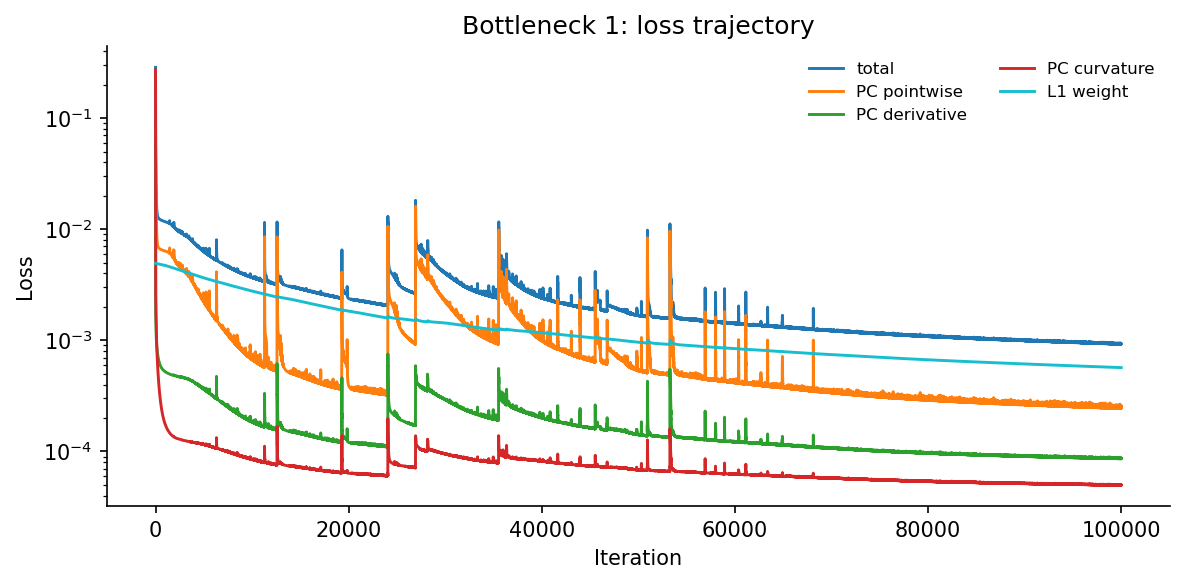

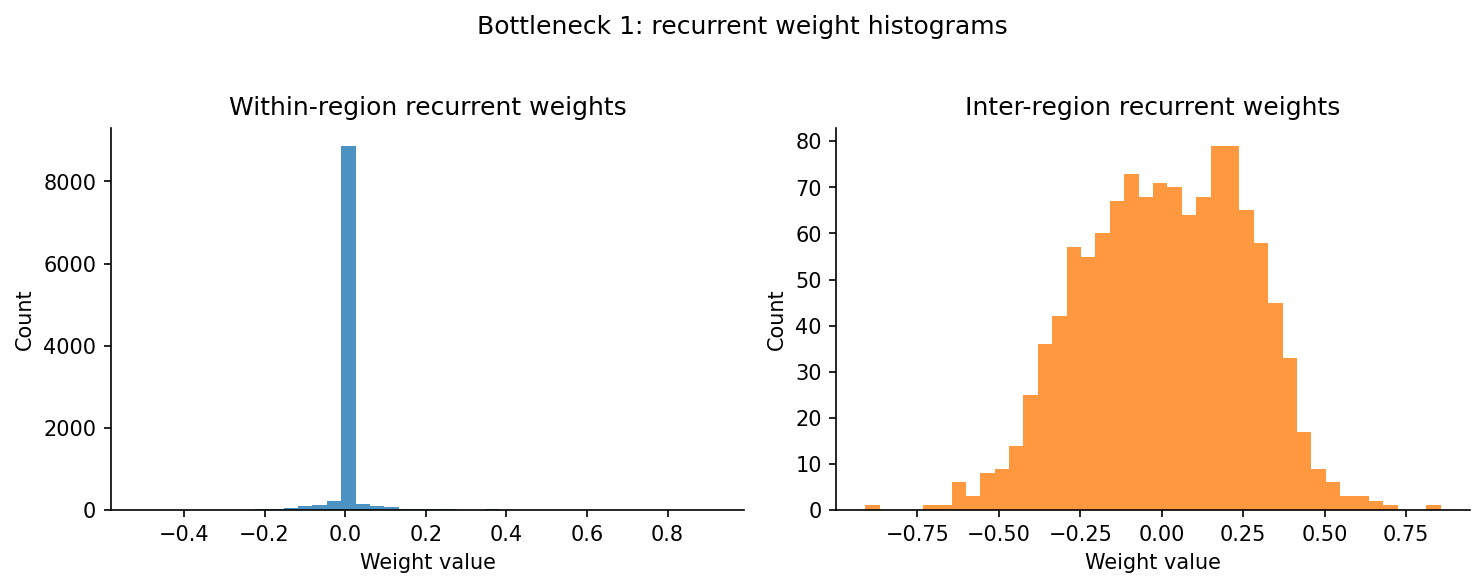

,metric_family,region,condition,mse,mae,r2,correlation
0,pc,ofc,face_interactive,0.0005,0.0165,0.9470,0.9732
1,pc,ofc,face_non_interactive,0.0002,0.0114,0.9832,0.9916
2,pc,ofc,object,0.0002,0.0108,0.9897,0.9949
3,pc,bla,face_interactive,0.0004,0.0154,0.9722,0.9860
4,pc,bla,face_non_interactive,0.0002,0.0106,0.9936,0.9968
5,pc,bla,object,0.0002,0.0110,0.9931,0.9965
6,pc,dmpfc,face_interactive,0.0004,0.0153,0.9068,0.9523
7,pc,dmpfc,face_non_interactive,0.0002,0.0102,0.9852,0.9926
8,pc,dmpfc,object,0.0002,0.0106,0.9792,0.9896
9,pc,accg,face_interactive,0.0003,0.0136,0.8833,0.9398


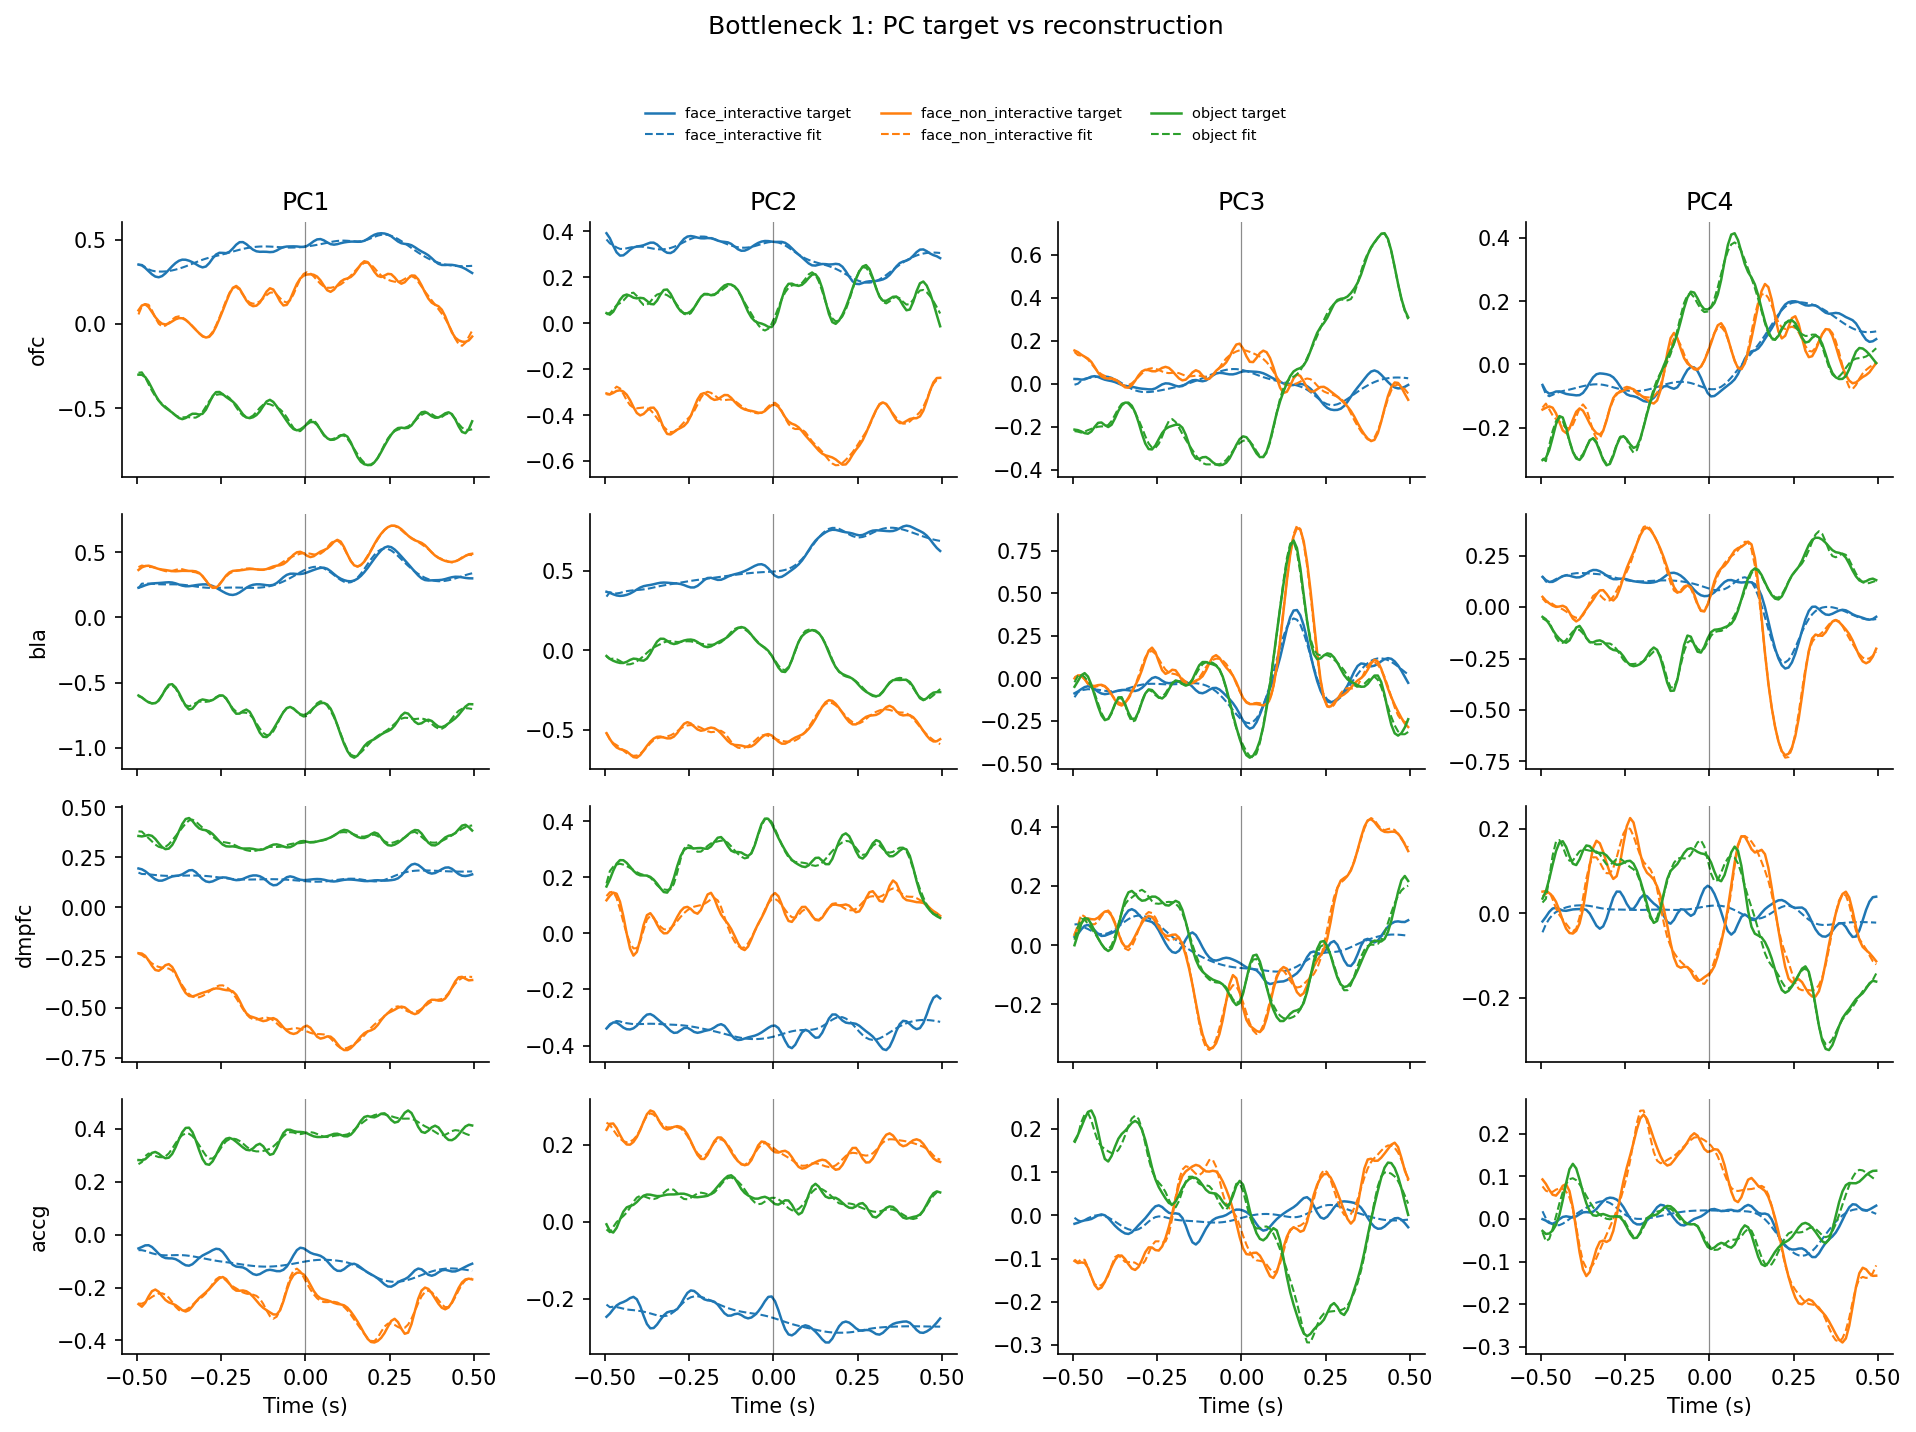

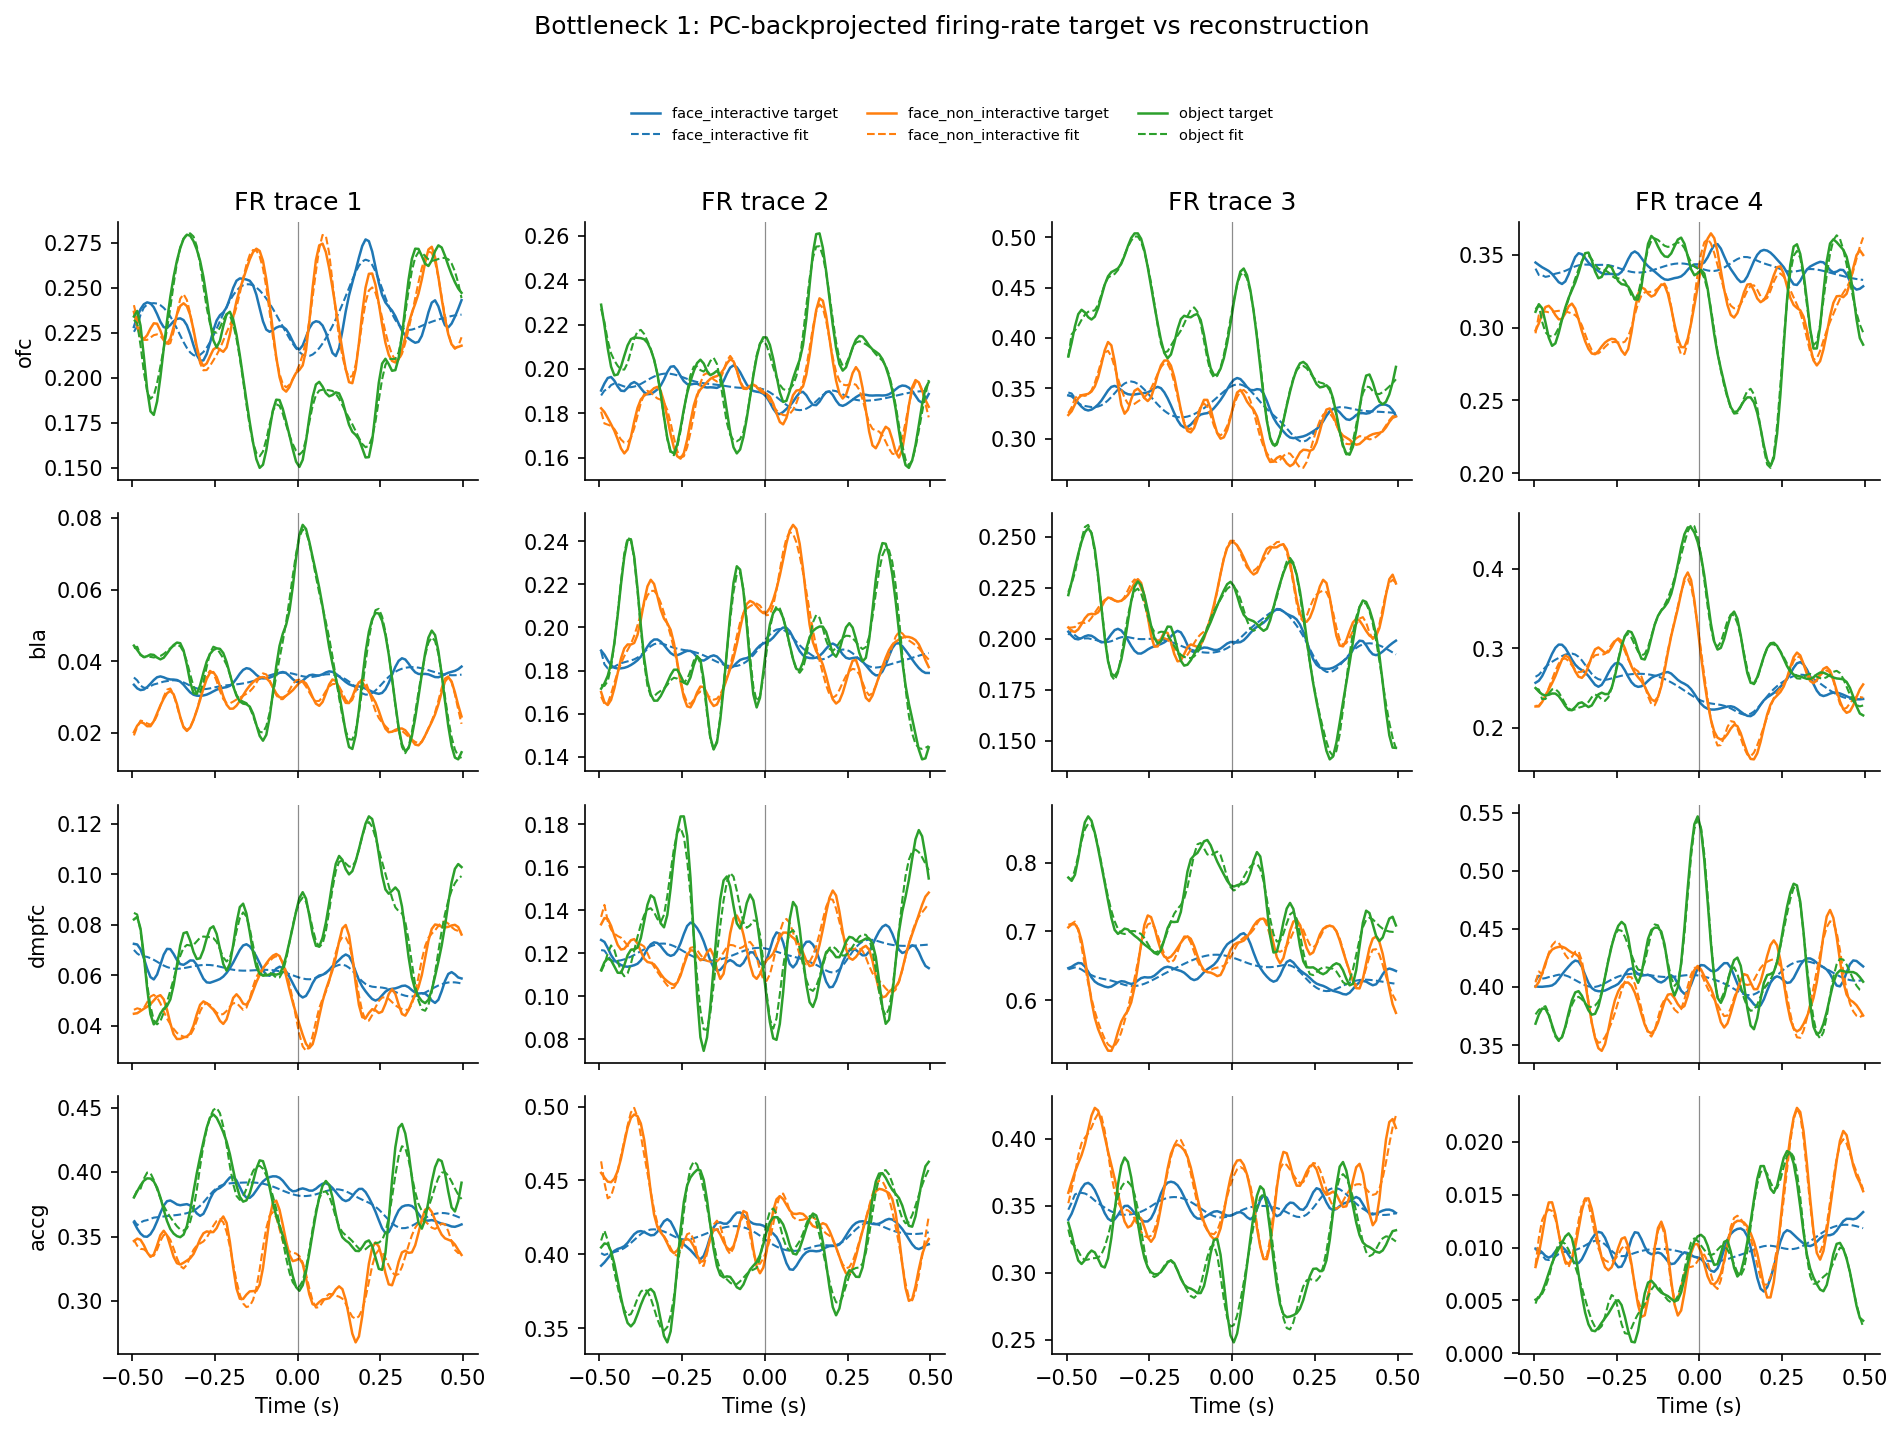

,metric_family,region,r2,correlation,mse,mae
0,pc,ofc,0.9733,0.9865,0.0003,0.0129
1,pc,bla,0.9863,0.9931,0.0003,0.0123
2,pc,dmpfc,0.9571,0.9782,0.0002,0.0121
3,pc,accg,0.9471,0.9729,0.0002,0.0108
4,fr,ofc,0.9994,0.9997,0.0000,0.0047
5,fr,bla,0.9997,0.9999,0.0000,0.0030
6,fr,dmpfc,0.9990,0.9995,0.0001,0.0049
7,fr,accg,0.9989,0.9995,0.0000,0.0039


In [ ]:
bottleneck_dim = 1
fit_1 = run_and_display_model(bottleneck_dim, overwrite=False, run_mode="load")

## 4. Model: Bottleneck 2

region_pcs seed=211382628:   0%|          | 0/100000 [00:00<?, ?iter/s]

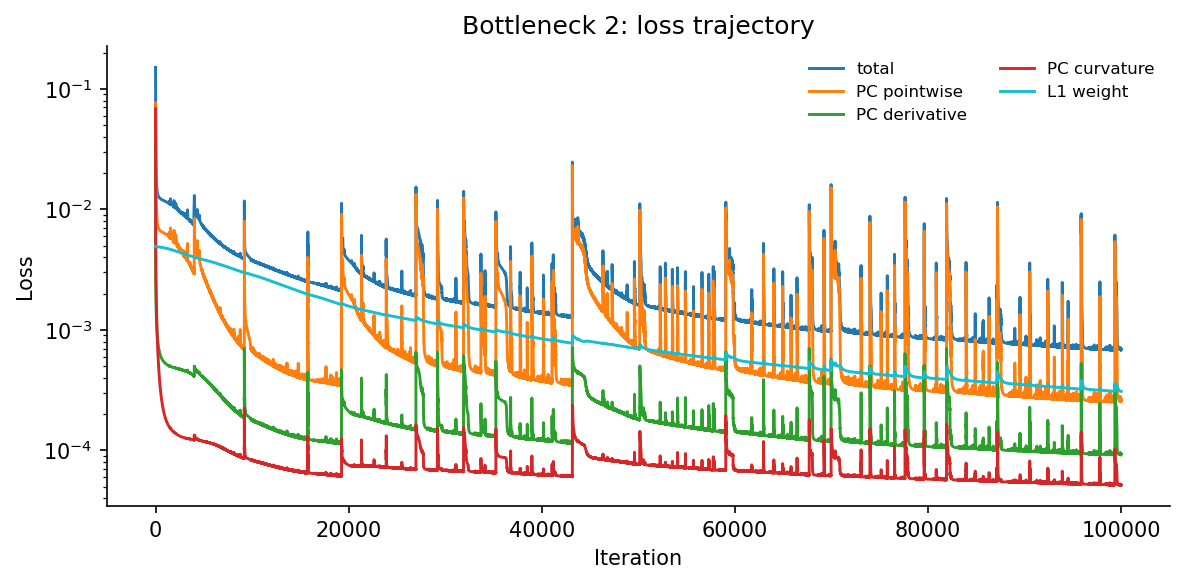

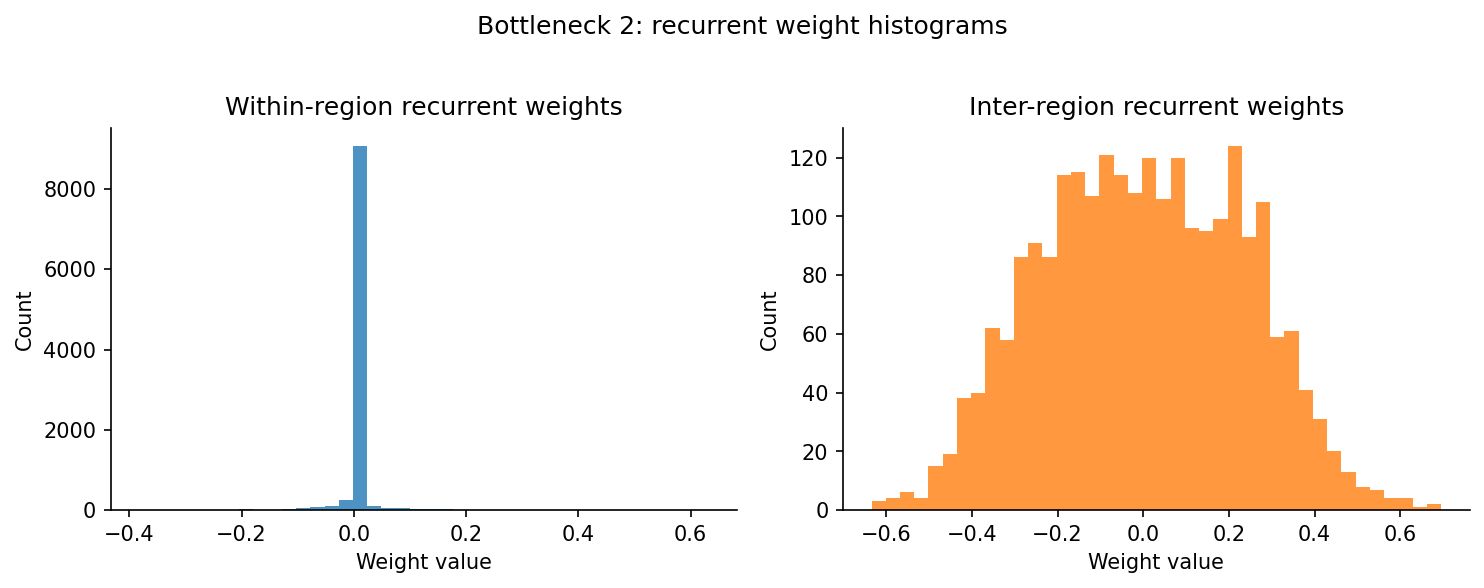

,metric_family,region,condition,mse,mae,r2,correlation
0,pc,ofc,face_interactive,0.0004,0.0162,0.9511,0.9753
1,pc,ofc,face_non_interactive,0.0002,0.0116,0.9830,0.9915
2,pc,ofc,object,0.0003,0.0133,0.9840,0.9920
3,pc,bla,face_interactive,0.0004,0.0158,0.9712,0.9855
4,pc,bla,face_non_interactive,0.0002,0.0111,0.9931,0.9965
5,pc,bla,object,0.0003,0.0138,0.9896,0.9948
6,pc,dmpfc,face_interactive,0.0003,0.0144,0.9188,0.9585
7,pc,dmpfc,face_non_interactive,0.0002,0.0101,0.9853,0.9927
8,pc,dmpfc,object,0.0003,0.0124,0.9714,0.9856
9,pc,accg,face_interactive,0.0003,0.0134,0.8847,0.9406


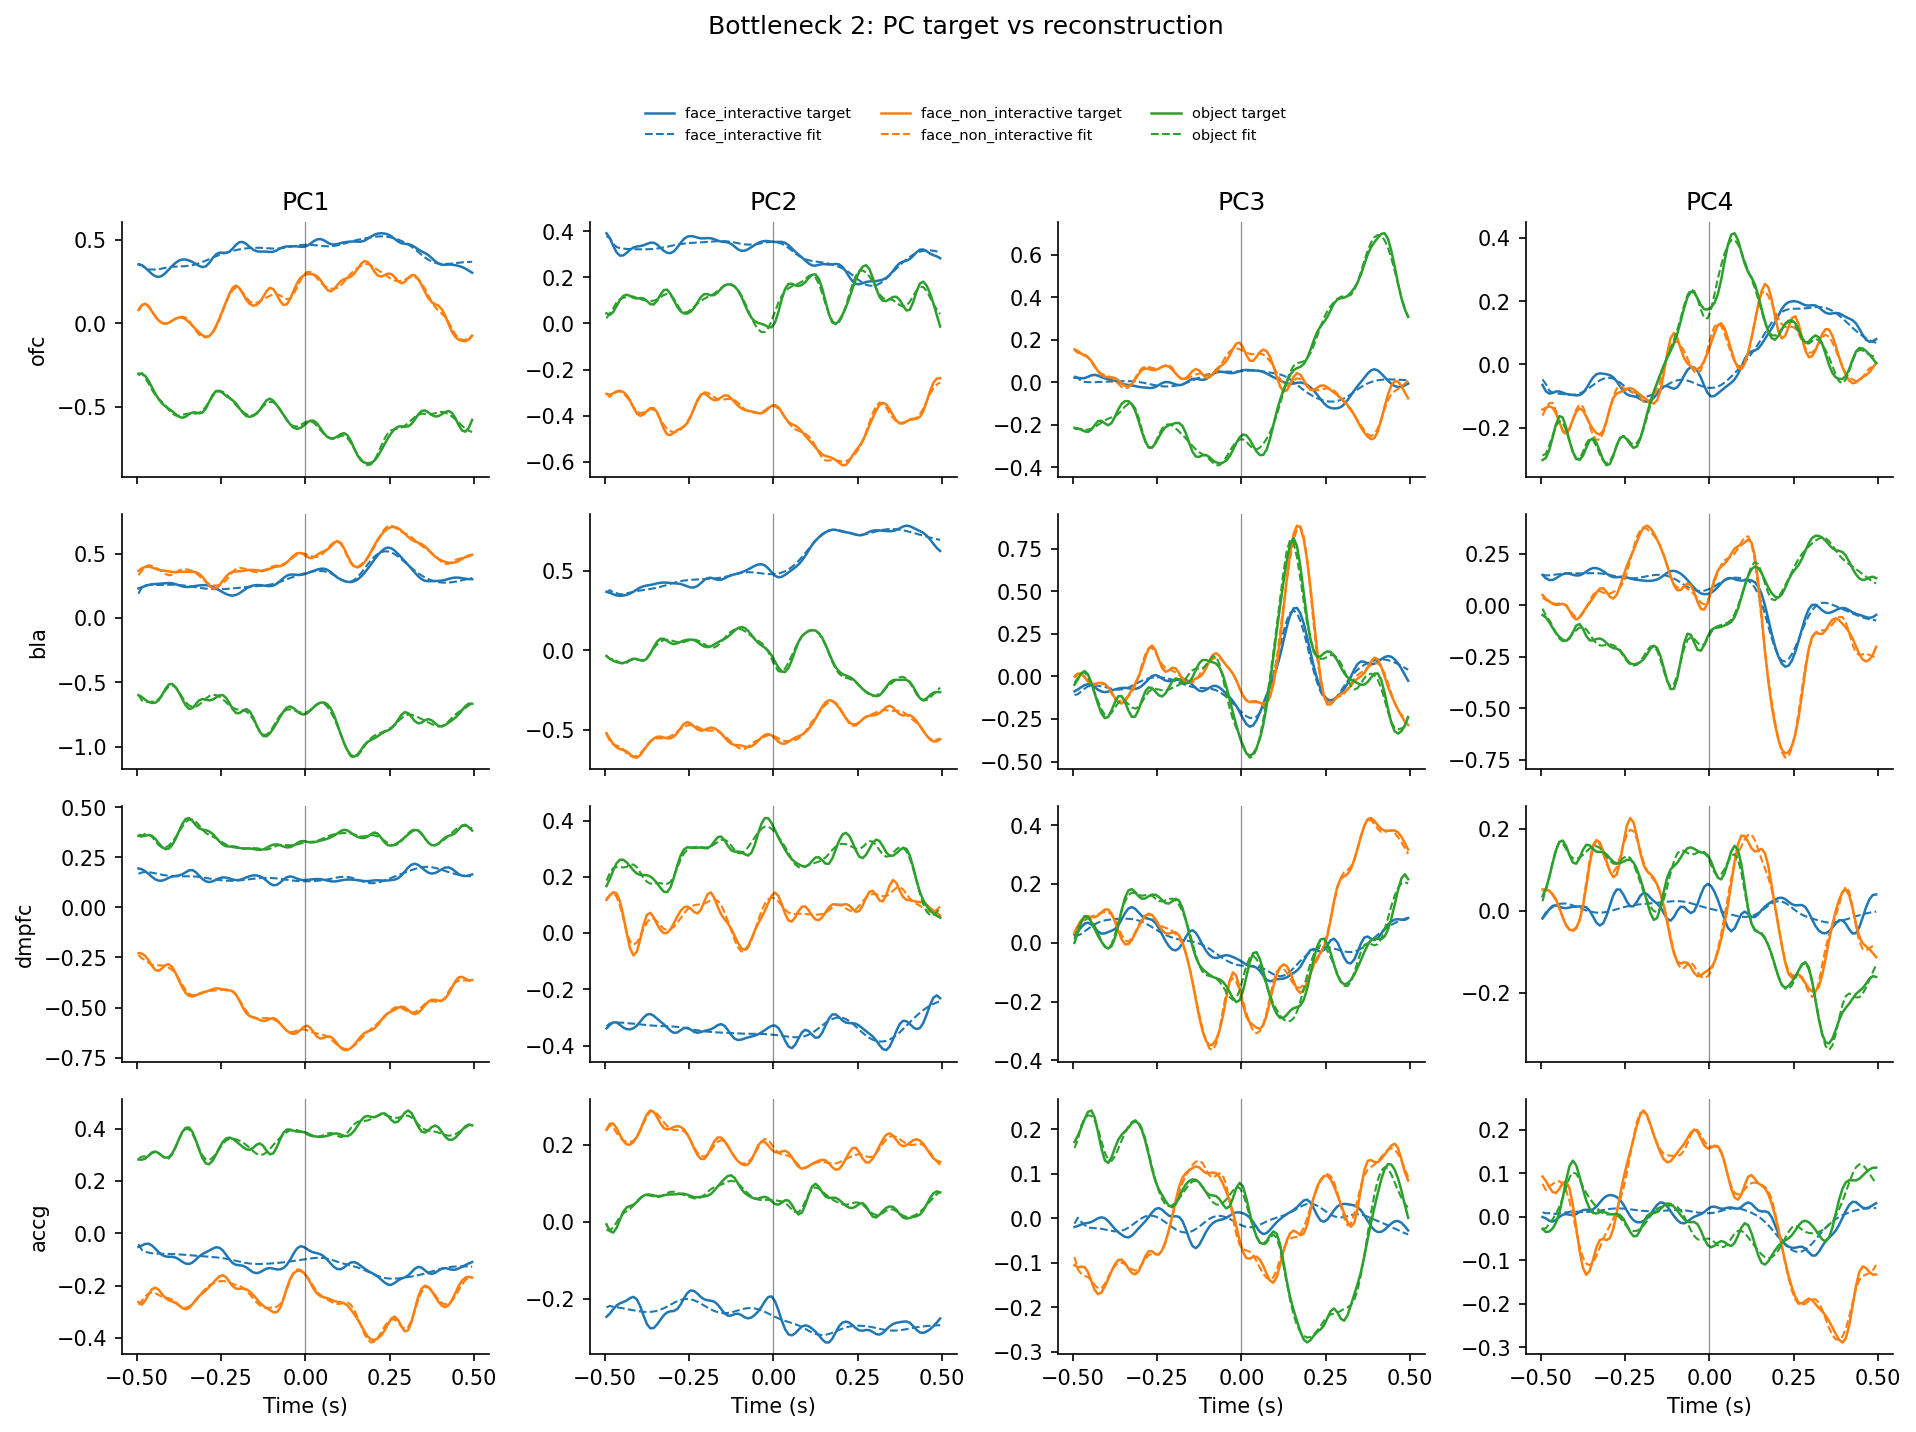

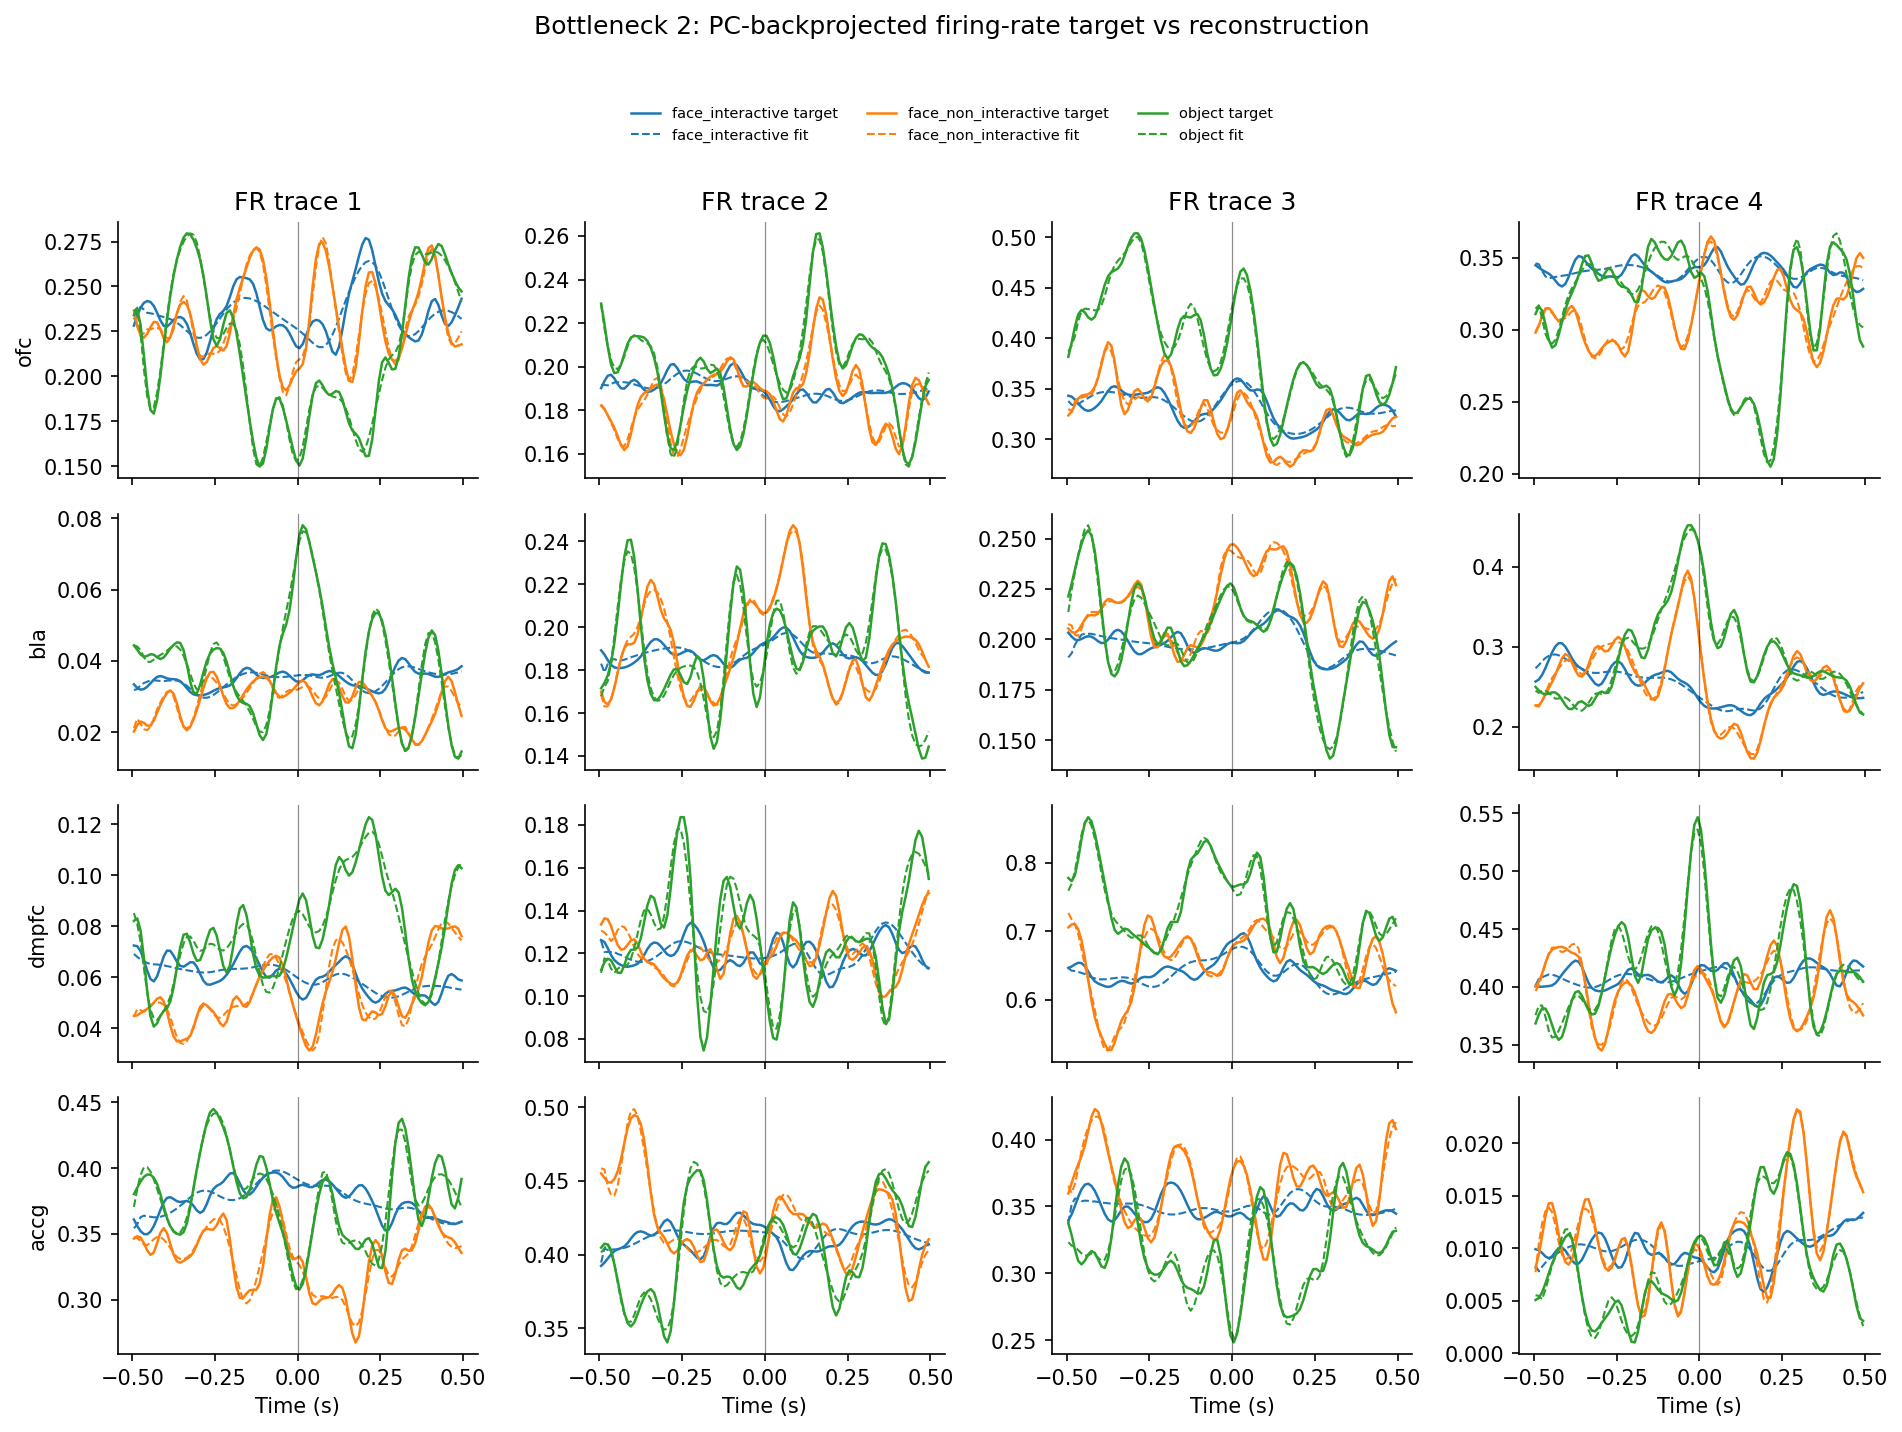

,metric_family,region,r2,correlation,mse,mae
0,pc,ofc,0.9727,0.9863,0.0003,0.0137
1,pc,bla,0.9846,0.9923,0.0003,0.0136
2,pc,dmpfc,0.9585,0.9789,0.0003,0.0123
3,pc,accg,0.9475,0.9732,0.0002,0.0107
4,fr,ofc,0.9994,0.9997,0.0001,0.0050
5,fr,bla,0.9997,0.9998,0.0000,0.0032
6,fr,dmpfc,0.9990,0.9995,0.0001,0.0050
7,fr,accg,0.9989,0.9995,0.0000,0.0039


In [ ]:
bottleneck_dim = 2
fit_2 = run_and_display_model(bottleneck_dim, overwrite=False, run_mode="load")

## 5. Model: Bottleneck 3

region_pcs seed=211382628:   0%|          | 0/100000 [00:00<?, ?iter/s]

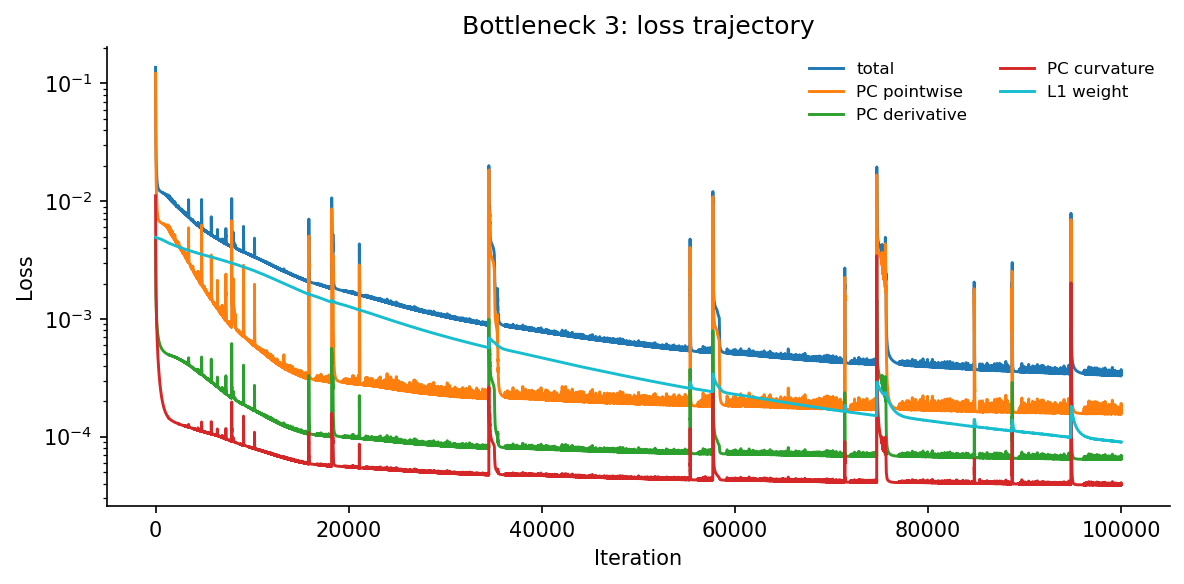

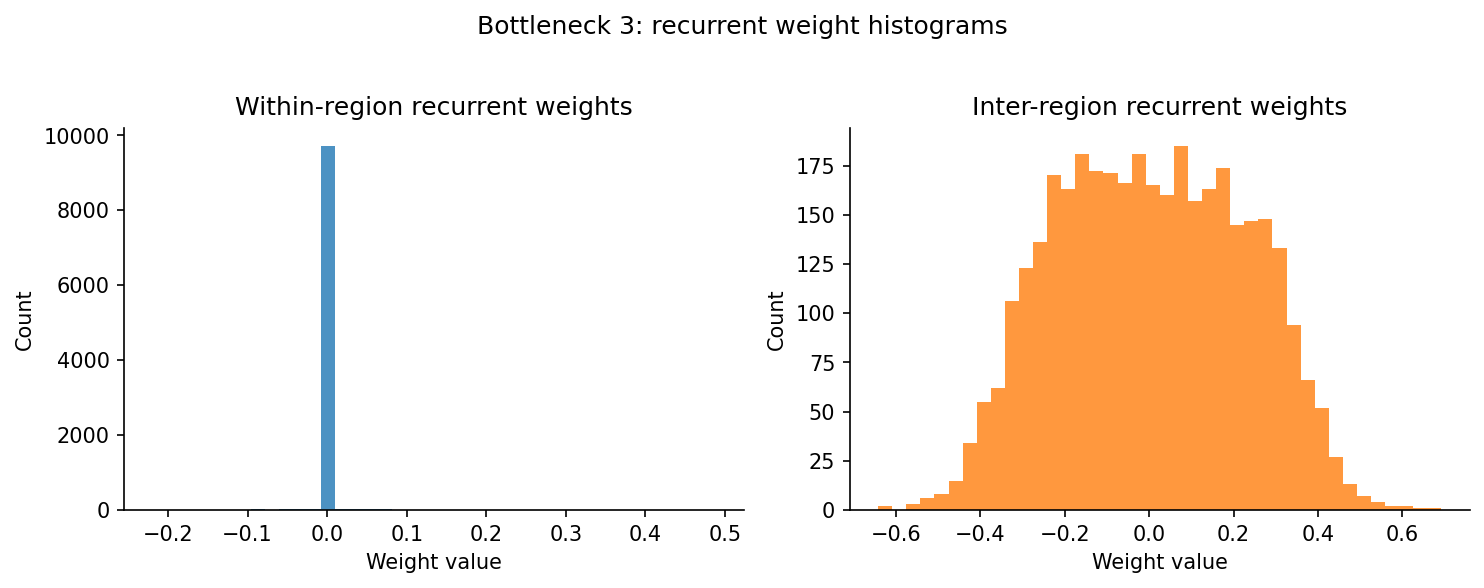

,metric_family,region,condition,mse,mae,r2,correlation
0,pc,ofc,face_interactive,0.0003,0.0139,0.9642,0.9820
1,pc,ofc,face_non_interactive,0.0001,0.0094,0.9891,0.9945
2,pc,ofc,object,0.0002,0.0108,0.9899,0.9949
3,pc,bla,face_interactive,0.0003,0.0137,0.9782,0.9891
4,pc,bla,face_non_interactive,0.0001,0.0090,0.9954,0.9977
5,pc,bla,object,0.0002,0.0105,0.9938,0.9969
6,pc,dmpfc,face_interactive,0.0003,0.0126,0.9383,0.9687
7,pc,dmpfc,face_non_interactive,0.0001,0.0080,0.9911,0.9955
8,pc,dmpfc,object,0.0001,0.0090,0.9856,0.9928
9,pc,accg,face_interactive,0.0002,0.0103,0.9326,0.9658


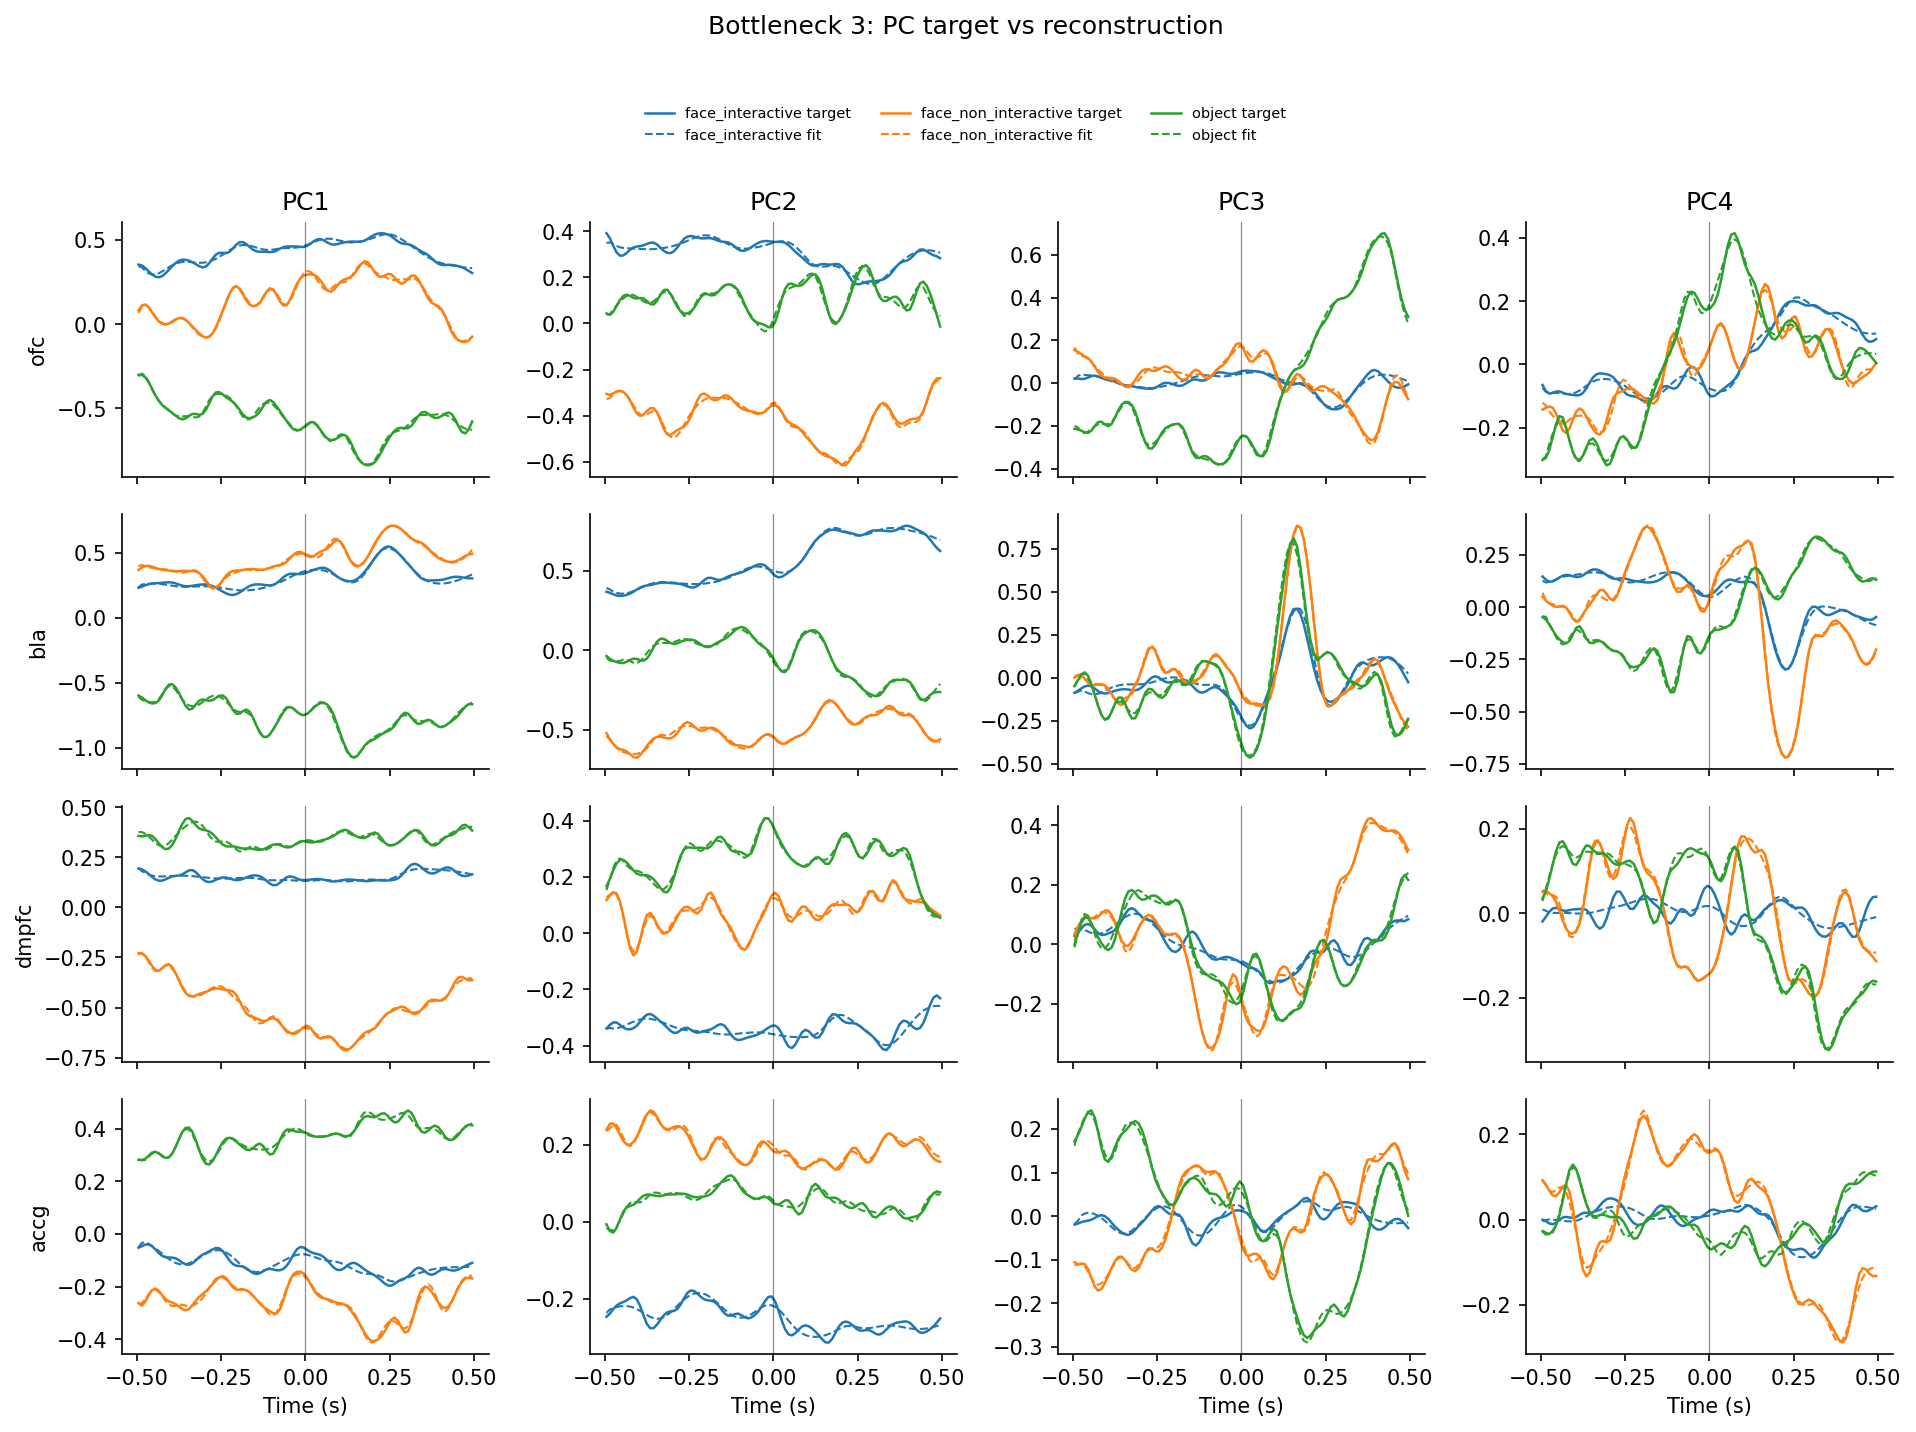

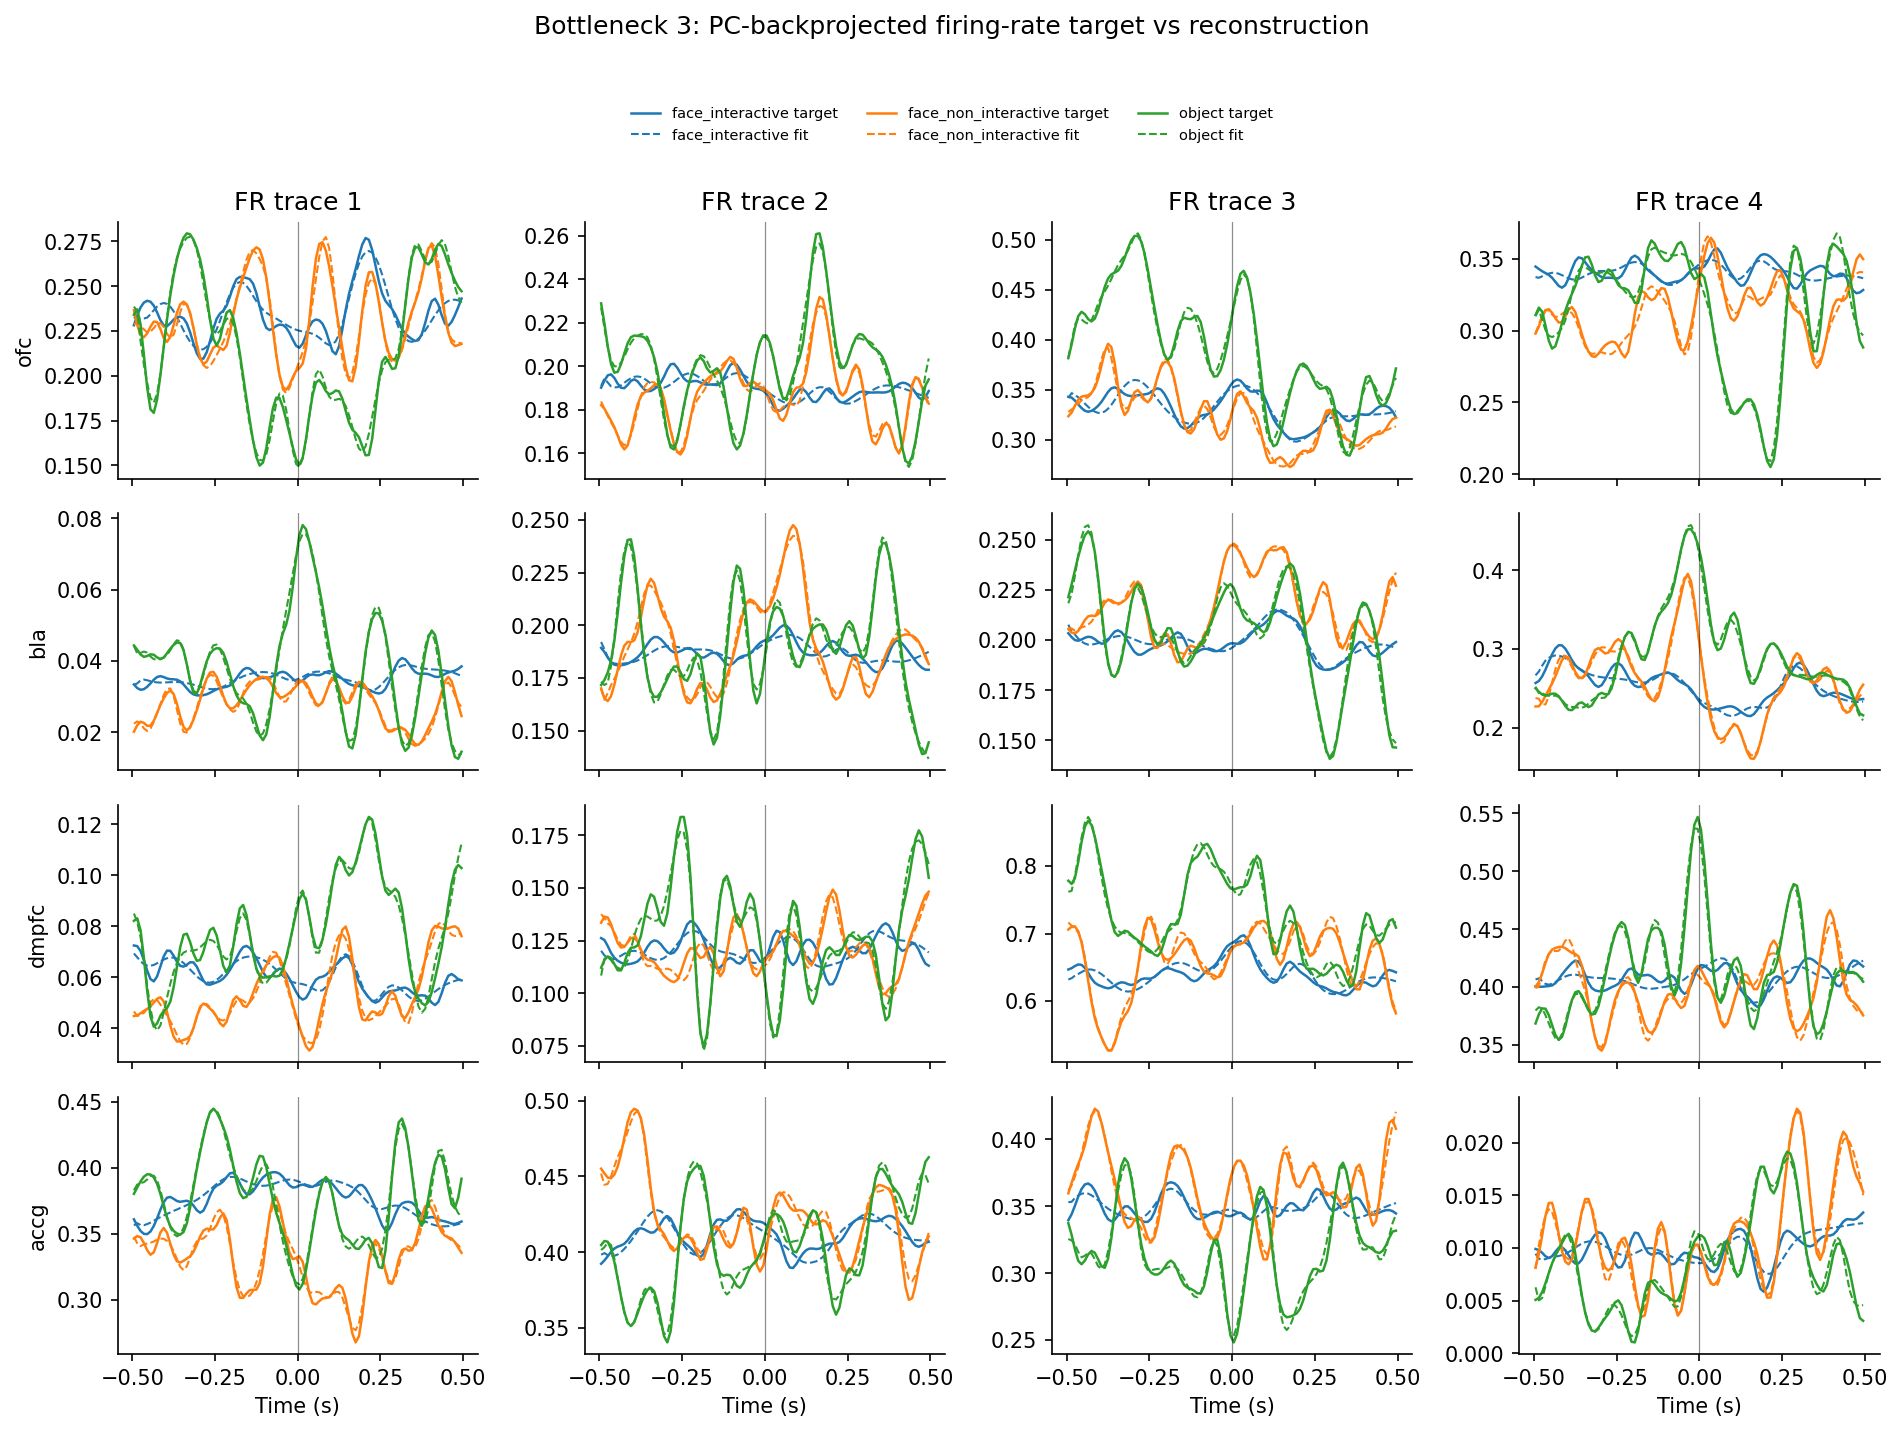

,metric_family,region,r2,correlation,mse,mae
0,pc,ofc,0.9811,0.9905,0.0002,0.0114
1,pc,bla,0.9891,0.9946,0.0002,0.0111
2,pc,dmpfc,0.9717,0.9857,0.0002,0.0099
3,pc,accg,0.9684,0.9840,0.0001,0.0084
4,fr,ofc,0.9996,0.9998,0.0000,0.0041
5,fr,bla,0.9998,0.9999,0.0000,0.0027
6,fr,dmpfc,0.9994,0.9997,0.0000,0.0041
7,fr,accg,0.9994,0.9997,0.0000,0.0031


In [ ]:
bottleneck_dim = 3
fit_3 = run_and_display_model(bottleneck_dim, overwrite=False, run_mode="load")

## 6. Model: Bottleneck 4

region_pcs seed=211382628:   0%|          | 0/100000 [00:00<?, ?iter/s]

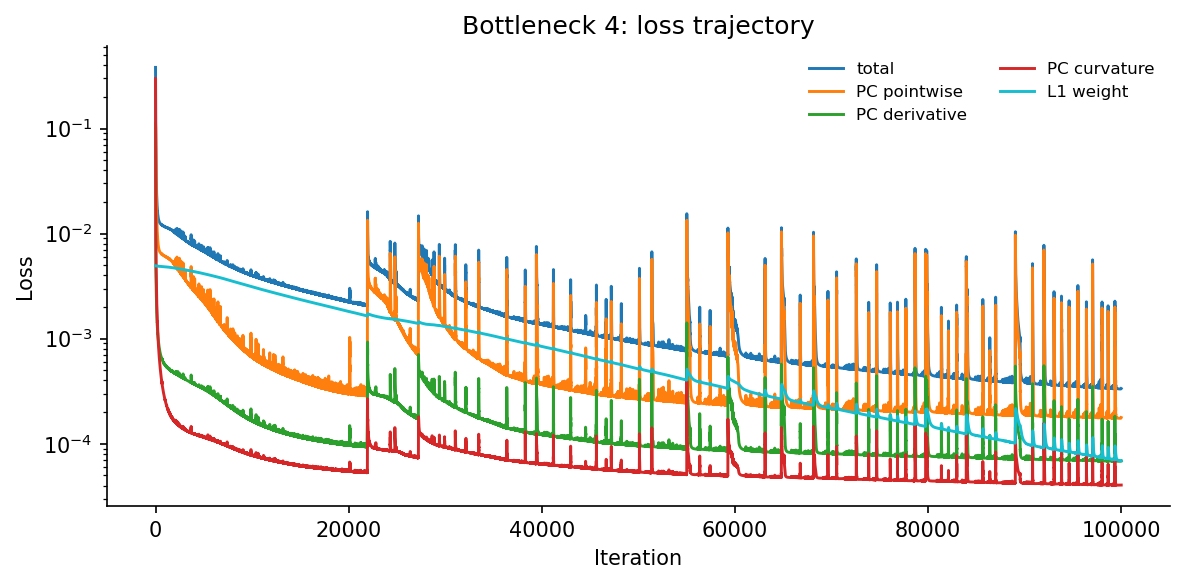

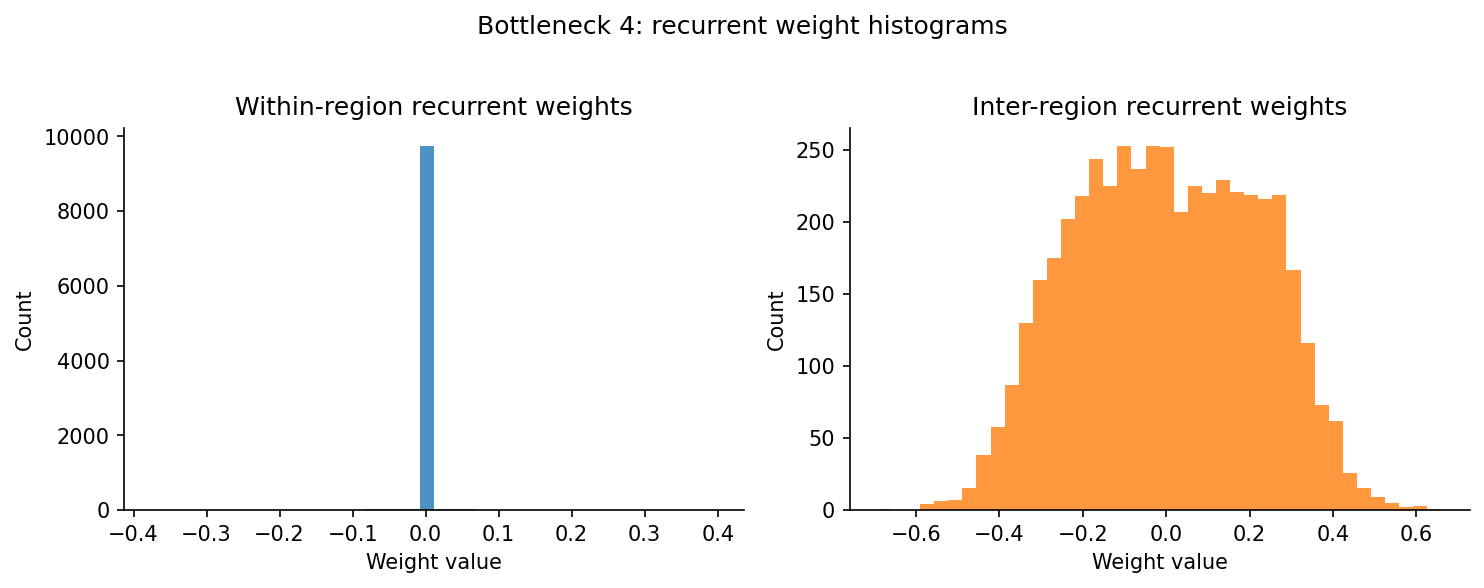

,metric_family,region,condition,mse,mae,r2,correlation
0,pc,ofc,face_interactive,0.0004,0.0149,0.9573,0.9784
1,pc,ofc,face_non_interactive,0.0001,0.0094,0.9888,0.9944
2,pc,ofc,object,0.0001,0.0093,0.9924,0.9962
3,pc,bla,face_interactive,0.0003,0.0144,0.9757,0.9878
4,pc,bla,face_non_interactive,0.0001,0.0096,0.9948,0.9974
5,pc,bla,object,0.0001,0.0096,0.9950,0.9975
6,pc,dmpfc,face_interactive,0.0003,0.0123,0.9410,0.9701
7,pc,dmpfc,face_non_interactive,0.0001,0.0080,0.9912,0.9956
8,pc,dmpfc,object,0.0001,0.0083,0.9874,0.9937
9,pc,accg,face_interactive,0.0002,0.0110,0.9211,0.9597


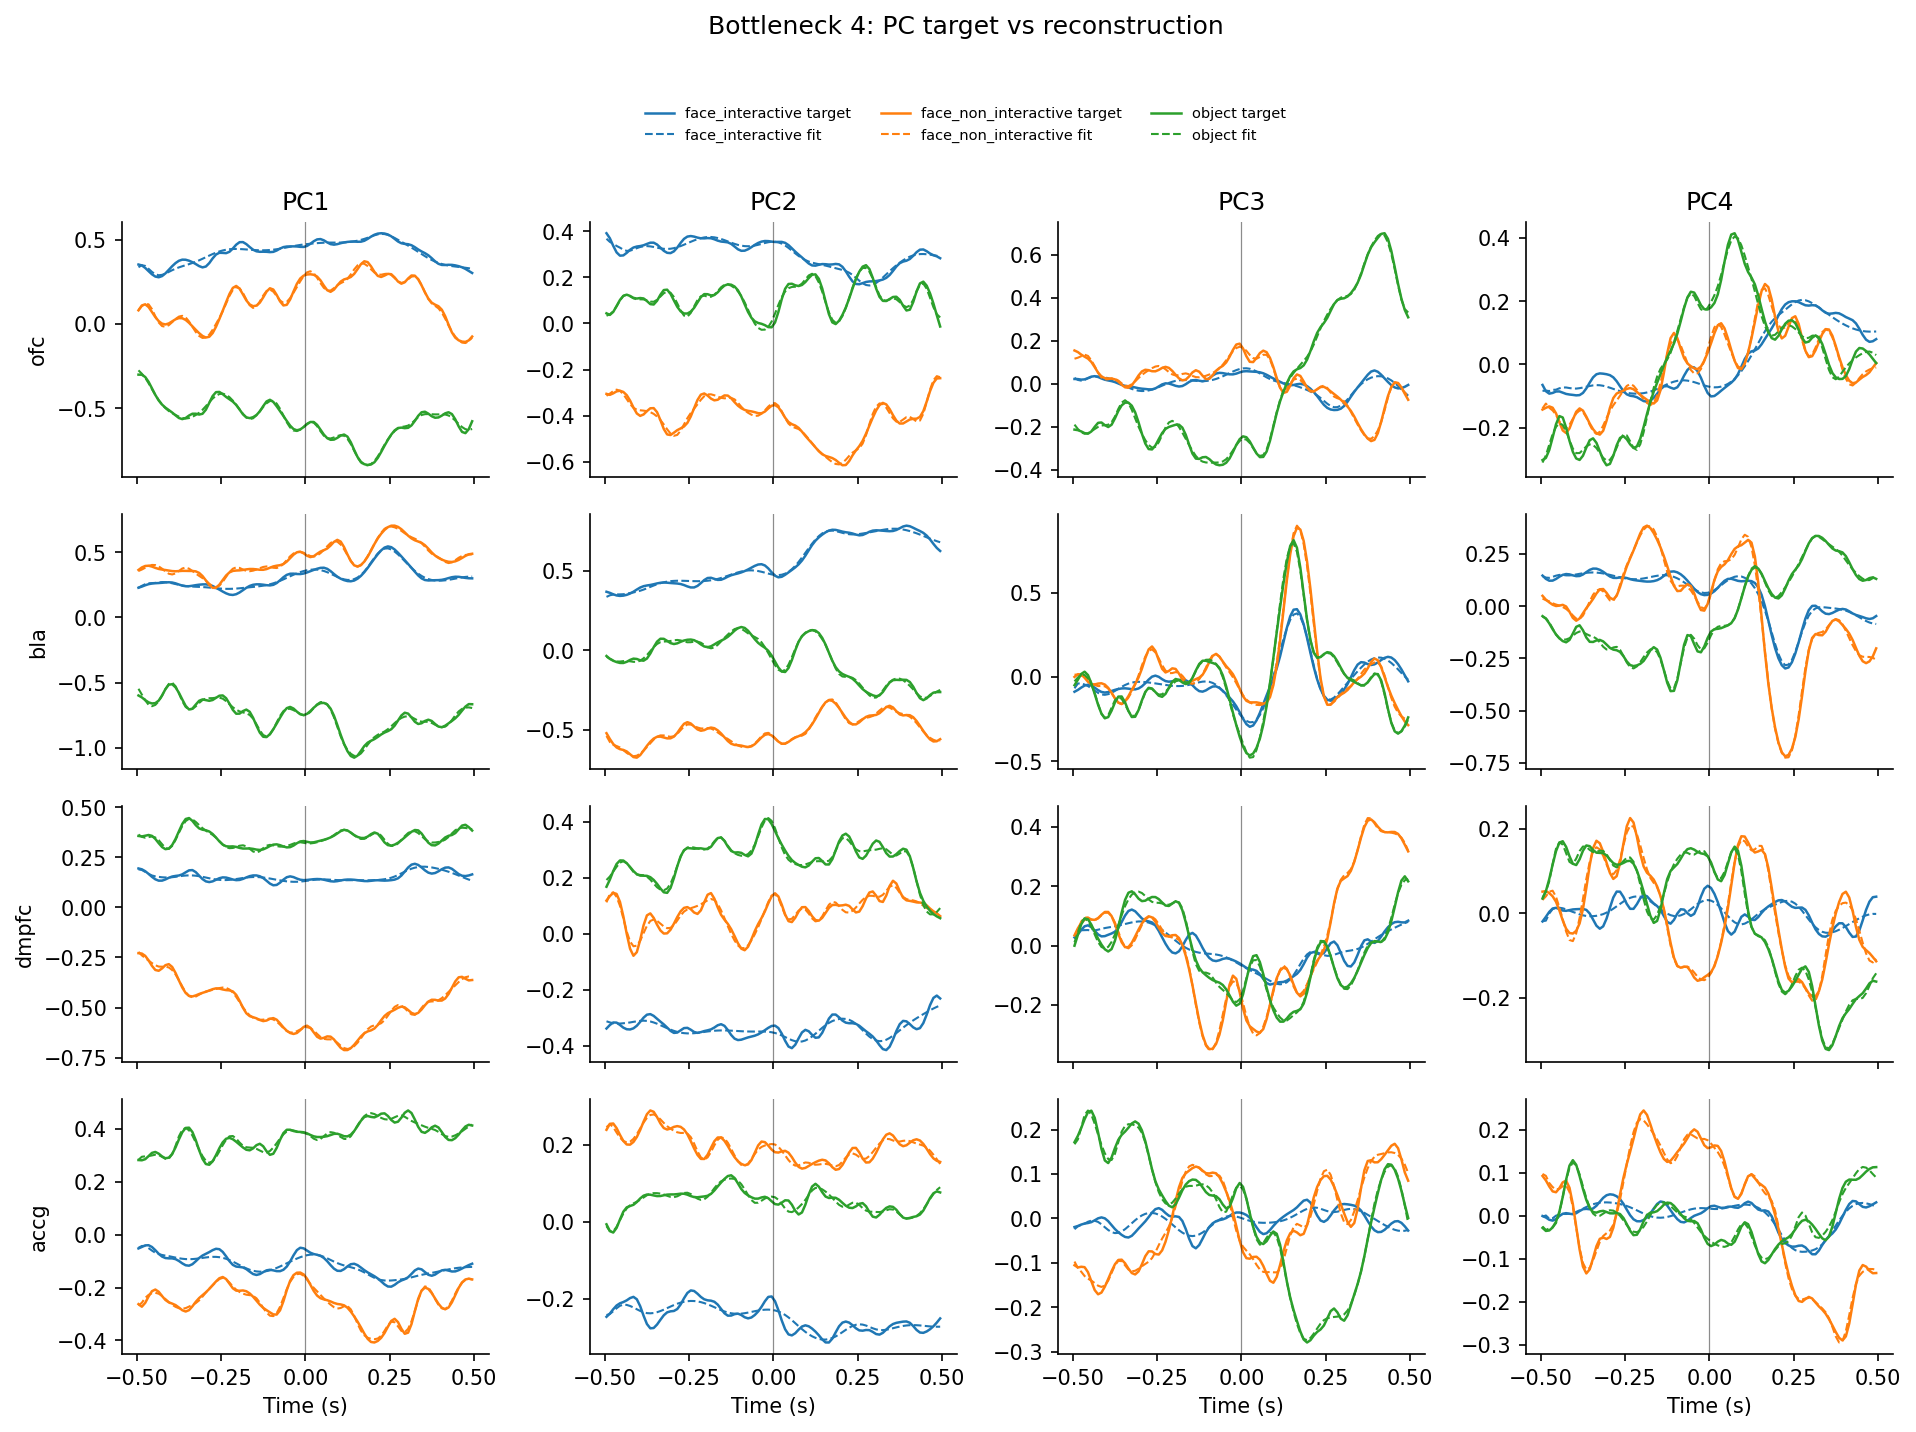

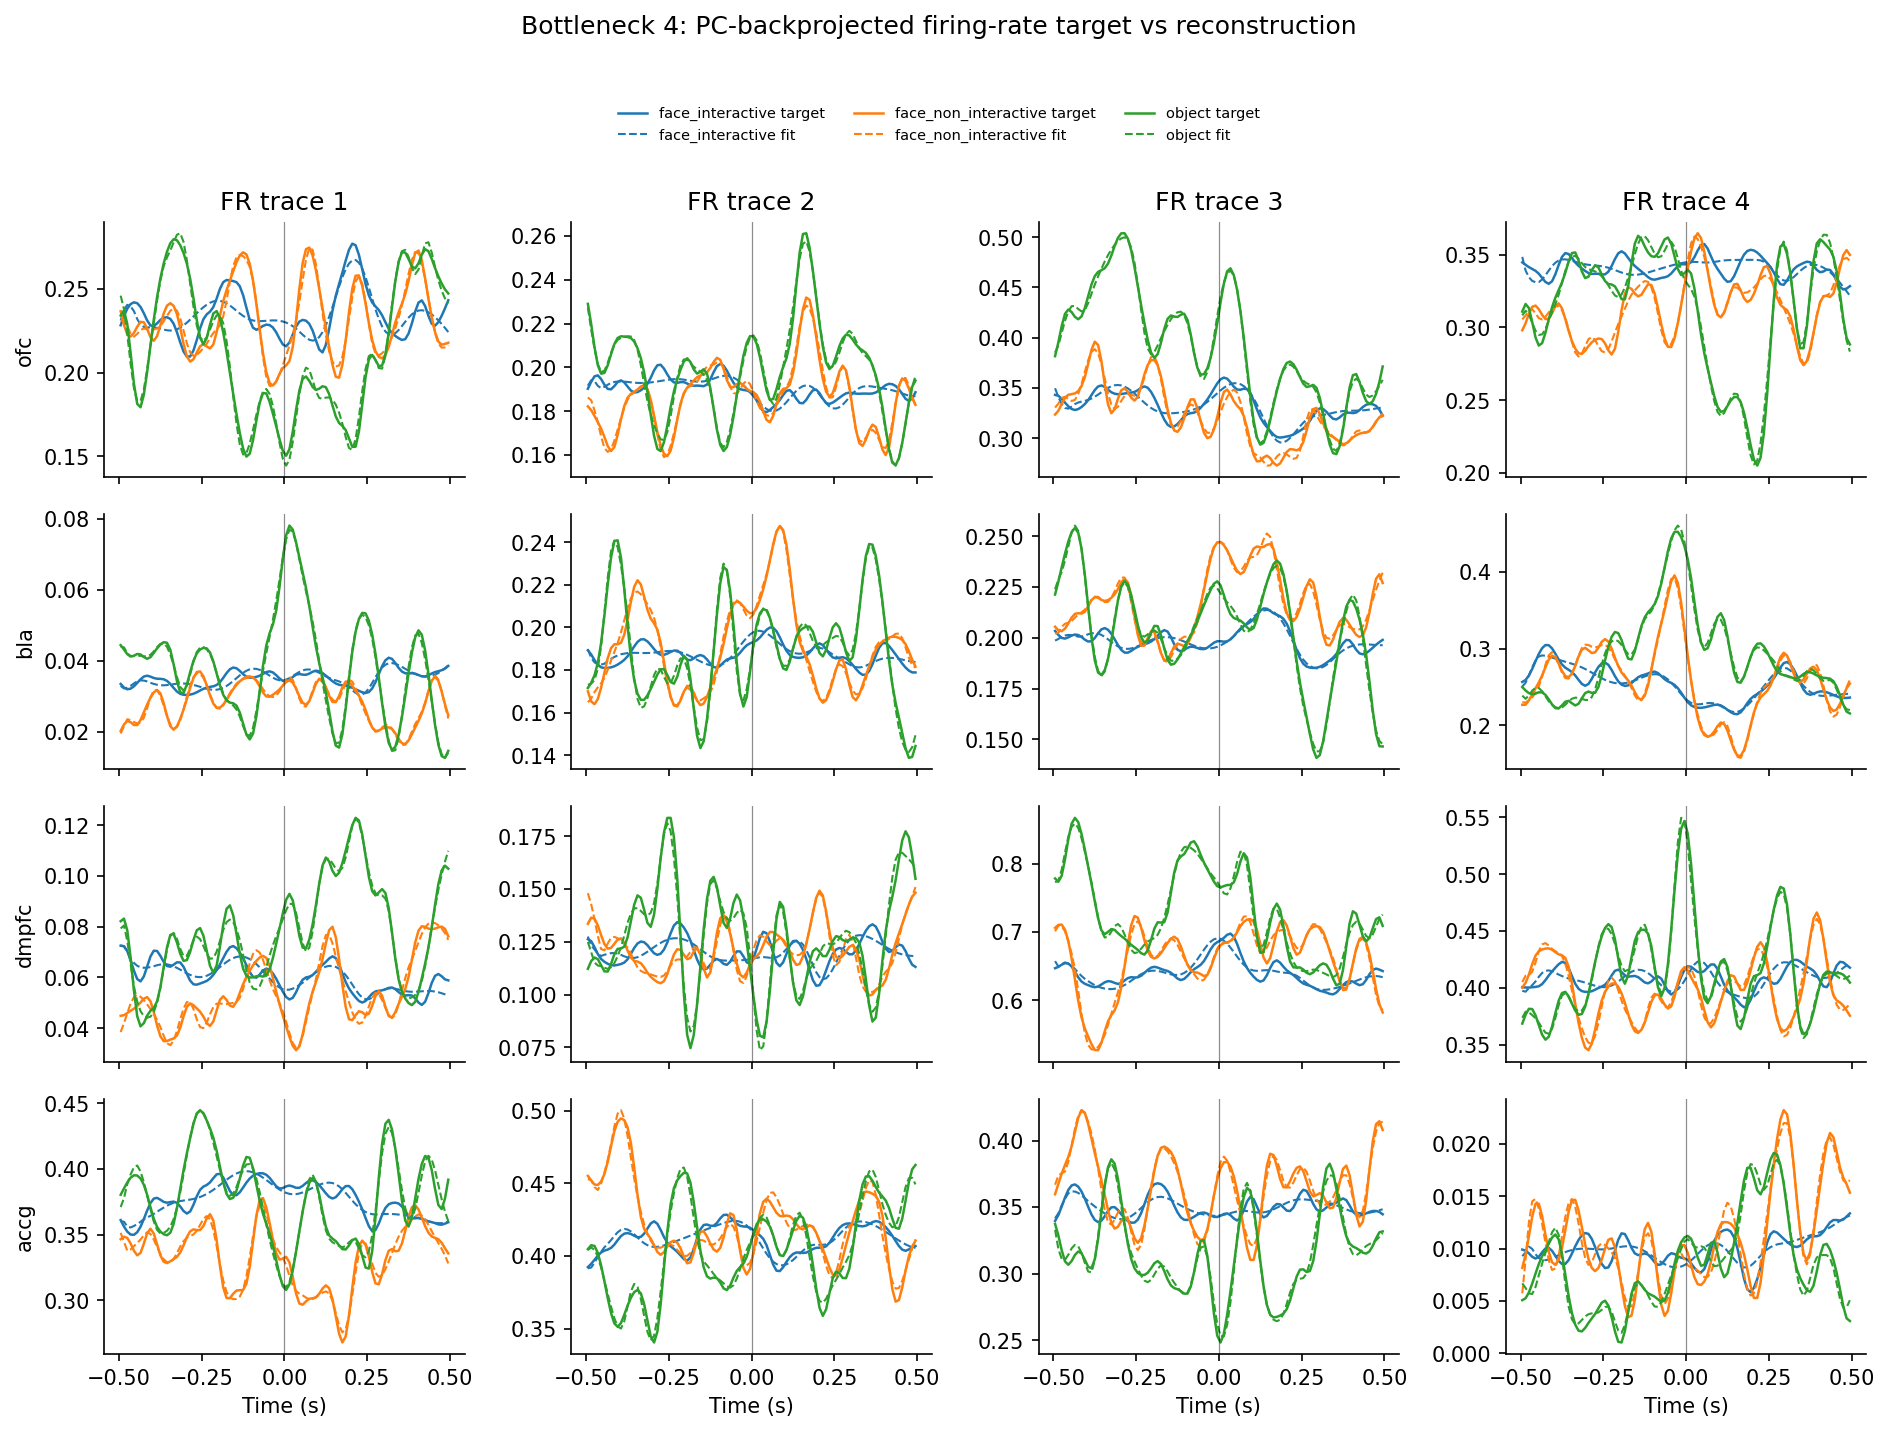

,metric_family,region,r2,correlation,mse,mae
0,pc,ofc,0.9795,0.9897,0.0002,0.0112
1,pc,bla,0.9885,0.9942,0.0002,0.0112
2,pc,dmpfc,0.9732,0.9864,0.0002,0.0095
3,pc,accg,0.9645,0.9820,0.0001,0.0087
4,fr,ofc,0.9996,0.9998,0.0000,0.0041
5,fr,bla,0.9998,0.9999,0.0000,0.0027
6,fr,dmpfc,0.9994,0.9997,0.0000,0.0040
7,fr,accg,0.9993,0.9996,0.0000,0.0032


In [ ]:
bottleneck_dim = 4
fit_4 = run_and_display_model(bottleneck_dim, overwrite=False, run_mode="load")

## 7 Model: Bottleneck 5

region_pcs seed=211382628:   0%|          | 0/100000 [00:00<?, ?iter/s]

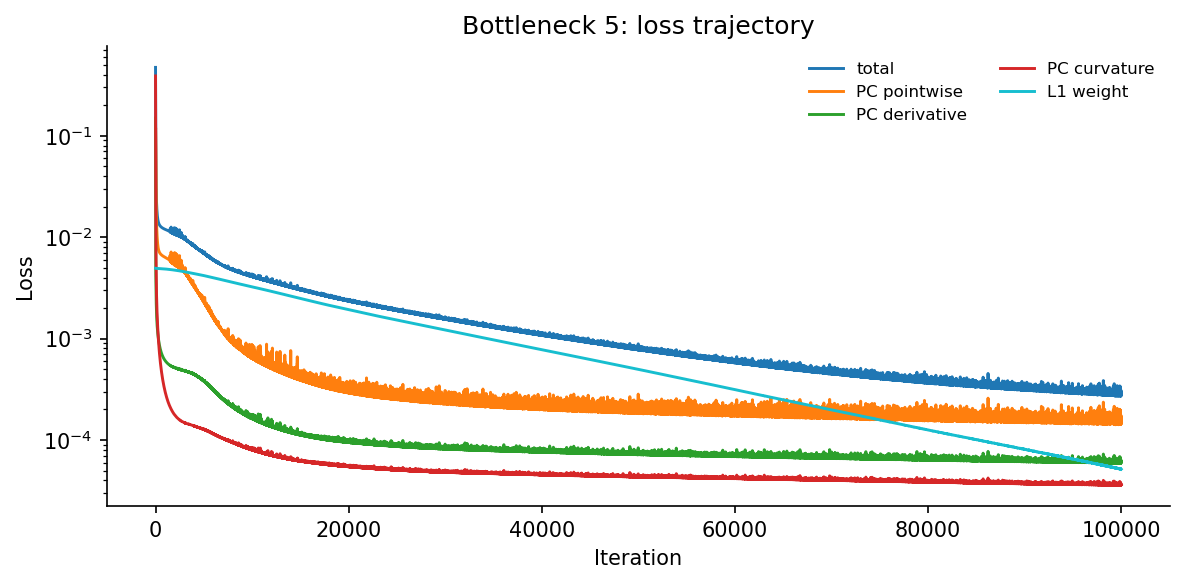

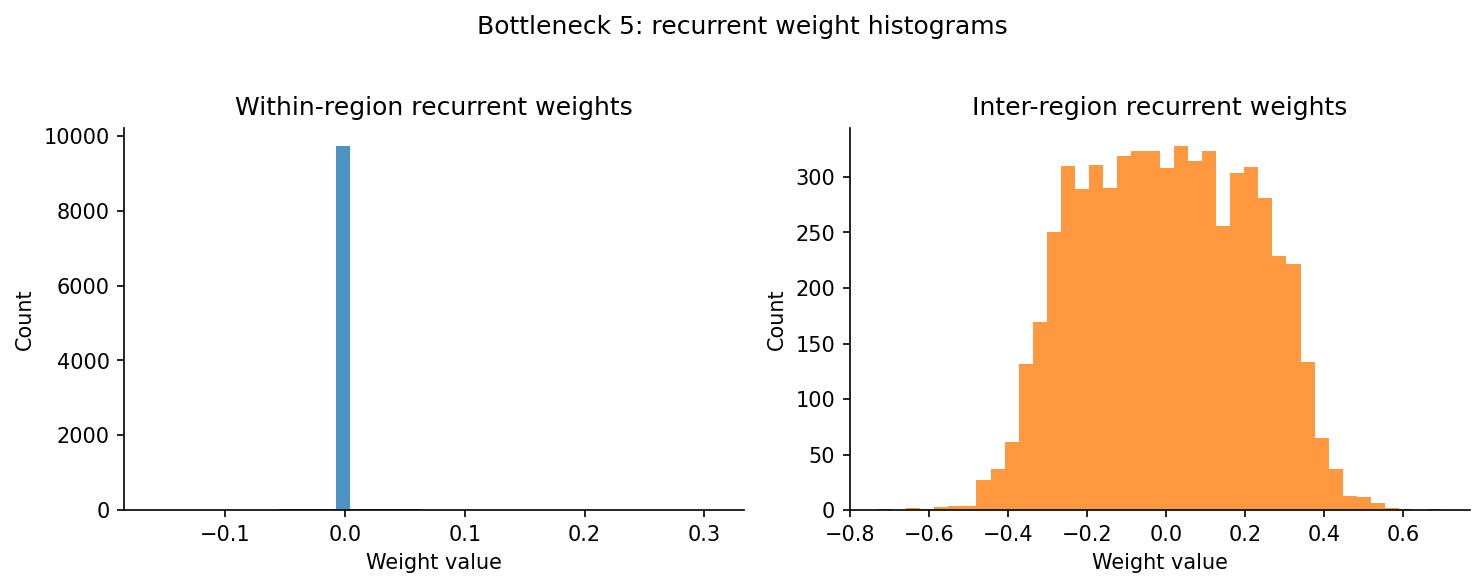

,metric_family,region,condition,mse,mae,r2,correlation
0,pc,ofc,face_interactive,0.0003,0.0144,0.9616,0.9806
1,pc,ofc,face_non_interactive,0.0001,0.0085,0.9909,0.9954
2,pc,ofc,object,0.0001,0.0091,0.9931,0.9965
3,pc,bla,face_interactive,0.0004,0.0148,0.9738,0.9868
4,pc,bla,face_non_interactive,0.0001,0.0085,0.9960,0.9980
5,pc,bla,object,0.0001,0.0089,0.9956,0.9978
6,pc,dmpfc,face_interactive,0.0002,0.0119,0.9446,0.9719
7,pc,dmpfc,face_non_interactive,0.0001,0.0075,0.9921,0.9960
8,pc,dmpfc,object,0.0001,0.0074,0.9900,0.9950
9,pc,accg,face_interactive,0.0002,0.0104,0.9313,0.9650


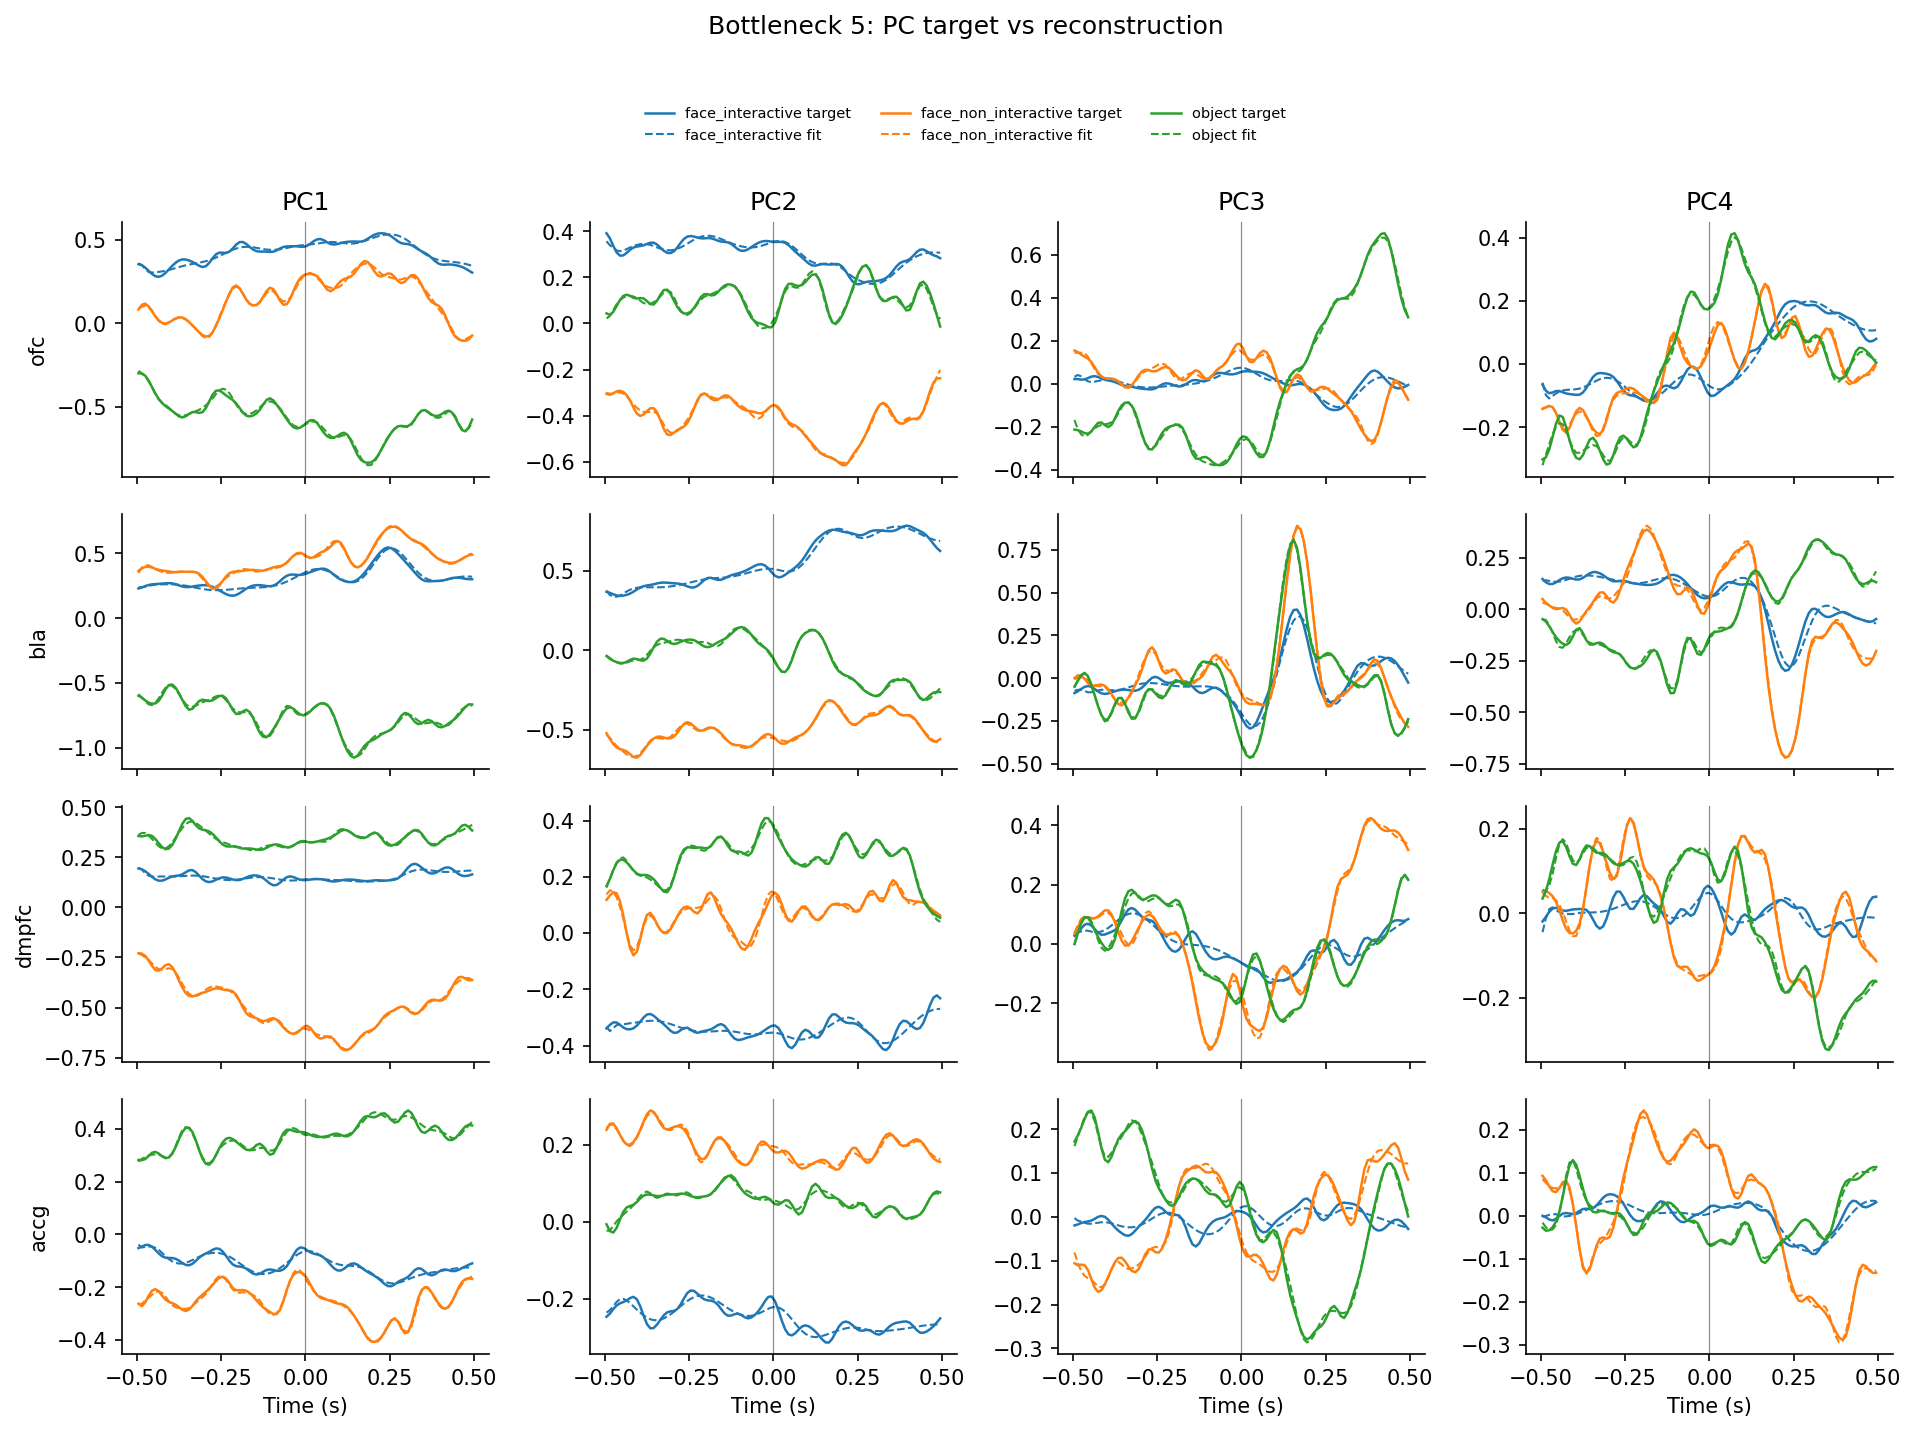

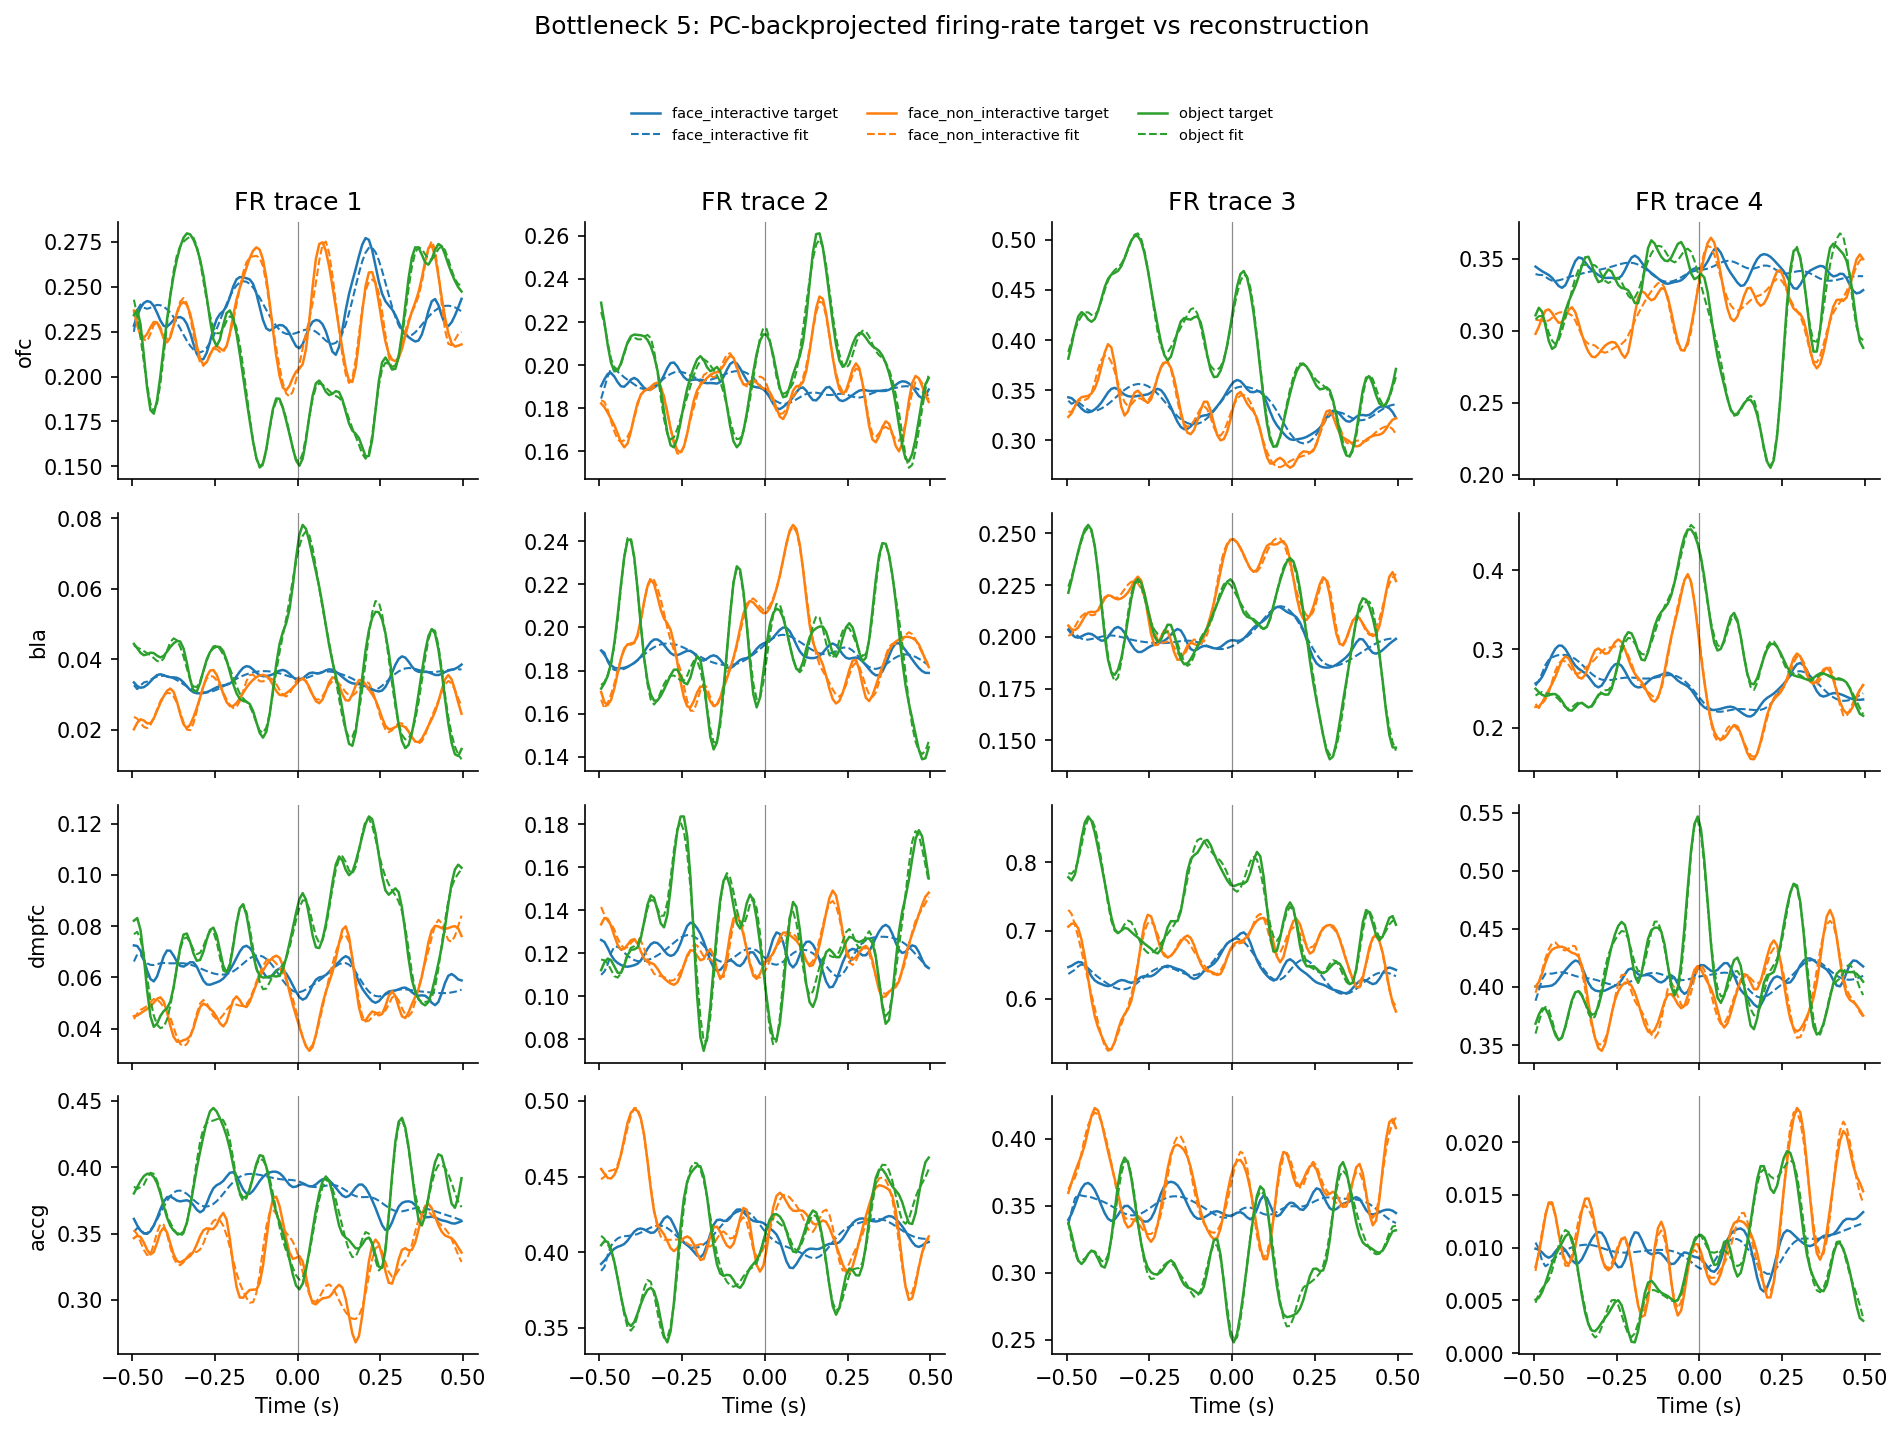

,metric_family,region,r2,correlation,mse,mae
0,pc,ofc,0.9819,0.9909,0.0002,0.0107
1,pc,bla,0.9885,0.9942,0.0002,0.0107
2,pc,dmpfc,0.9756,0.9877,0.0001,0.0090
3,pc,accg,0.9696,0.9846,0.0001,0.0080
4,fr,ofc,0.9996,0.9998,0.0000,0.0038
5,fr,bla,0.9998,0.9999,0.0000,0.0025
6,fr,dmpfc,0.9995,0.9997,0.0000,0.0037
7,fr,accg,0.9994,0.9997,0.0000,0.0030


In [ ]:
bottleneck_dim = 5
fit_5 = run_and_display_model(bottleneck_dim, overwrite=True, run_mode="train")

## 7. Compare Reconstruction Metrics Across Models

,bottleneck_dim,metric_family,region,r2,correlation,mse,mae
0,1,pc,ofc,0.9733,0.9865,0.0003,0.0129
1,1,pc,bla,0.9863,0.9931,0.0003,0.0123
2,1,pc,dmpfc,0.9571,0.9782,0.0002,0.0121
3,1,pc,accg,0.9471,0.9729,0.0002,0.0108
4,1,fr,ofc,0.9994,0.9997,0.0000,0.0047
5,1,fr,bla,0.9997,0.9999,0.0000,0.0030
6,1,fr,dmpfc,0.9990,0.9995,0.0001,0.0049
7,1,fr,accg,0.9989,0.9995,0.0000,0.0039
8,2,pc,ofc,0.9727,0.9863,0.0003,0.0137
9,2,pc,bla,0.9846,0.9923,0.0003,0.0136


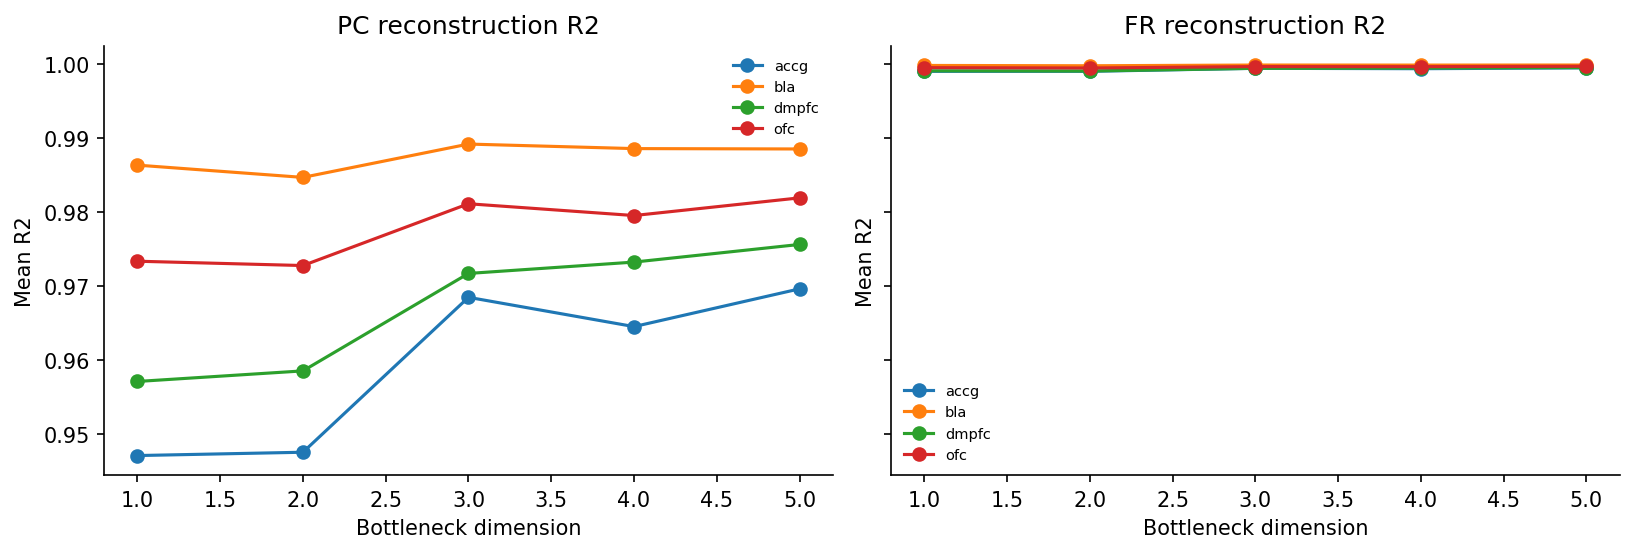

In [9]:
comparison_rows = []
for bottleneck_dim in [1, 2, 3, 4, 5]:
    fit = train_or_load_model(bottleneck_dim, overwrite=False, run_mode="load")
    replay = fit["replay"]
    pc_metrics, fr_metrics = summarize_reconstruction_metrics(replay)
    for _, row in pc_metrics.groupby(["region"], sort=False).mean(numeric_only=True).reset_index().iterrows():
        comparison_rows.append({"bottleneck_dim": bottleneck_dim, "metric_family": "pc", "region": row["region"], "r2": row["r2"], "correlation": row["correlation"], "mse": row["mse"], "mae": row["mae"]})
    for _, row in fr_metrics.groupby(["region"], sort=False).mean(numeric_only=True).reset_index().iterrows():
        comparison_rows.append({"bottleneck_dim": bottleneck_dim, "metric_family": "fr", "region": row["region"], "r2": row["r2"], "correlation": row["correlation"], "mse": row["mse"], "mae": row["mae"]})

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.round(4))

if not comparison_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8), dpi=140, sharey=True)
    for metric_family, ax in zip(["pc", "fr"], axes):
        sub = comparison_df[comparison_df["metric_family"] == metric_family]
        for region in sorted(sub["region"].unique()):
            region_sub = sub[sub["region"] == region]
            ax.plot(region_sub["bottleneck_dim"], region_sub["r2"], marker="o", label=region)
        ax.set_xlabel("Bottleneck dimension")
        ax.set_ylabel("Mean R2")
        ax.set_title(f"{metric_family.upper()} reconstruction R2")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=7)
    fig.tight_layout()
    display_figure(fig)